In [120]:
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.stats import chi2
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display
from scipy.stats import chi2_contingency

In [2]:
reg_df = pd.read_excel('long_df_SA.xlsx')

In [3]:
for c in reg_df.columns:
    print(c)

respondent_id
task_num
cj_var
candidate
profile
choice
outcome
cj_pair
status
invitation
relevance
lurker
recnum
code
testdata
itime
Q1
Q3a
Identitya
Identityb
Identityc
Identityd
Identitye
Identityf
Identityg
Identityh
Identityi
Trusta
Trustb
Trustc
Trustd
Truste
Authoritara
Authoritarb
Authoritarc
Authoritard
Authoritare
Authoritarf
Authoritarg
Authoritarh
Authoritari
Contacta
Contactb
Contactc
Contactd
Contacte
Contactf
Contactg
Valencea
Valenceb
Valencec
Valenced
Valencee
Valencef
Valenceg
Valenceh
Supporta
Q5
Q6
Q41
Q41_2_text
Q42
Q43
Q44
random_15653086
random_15662935
random_15662941
random_15662944
random_15662950
random_15662945
random_1375280
t_insert
t_edit
date_0
date_1
date_2
date_3
date_4
date_5
date_6
date_7
date_8
date_9
date_10
date_11
Browser
BrowserVersion
OS
Device
Referer
Unsubscribed
Language
Age_resp
Female_resp
Education_resp
Income
Locality
identity_civic_index
identity_ethnic_index
trust_index
authoritar_index
contact_index
valence_index
cj_num
region
motivati

# Проверка рандомизации

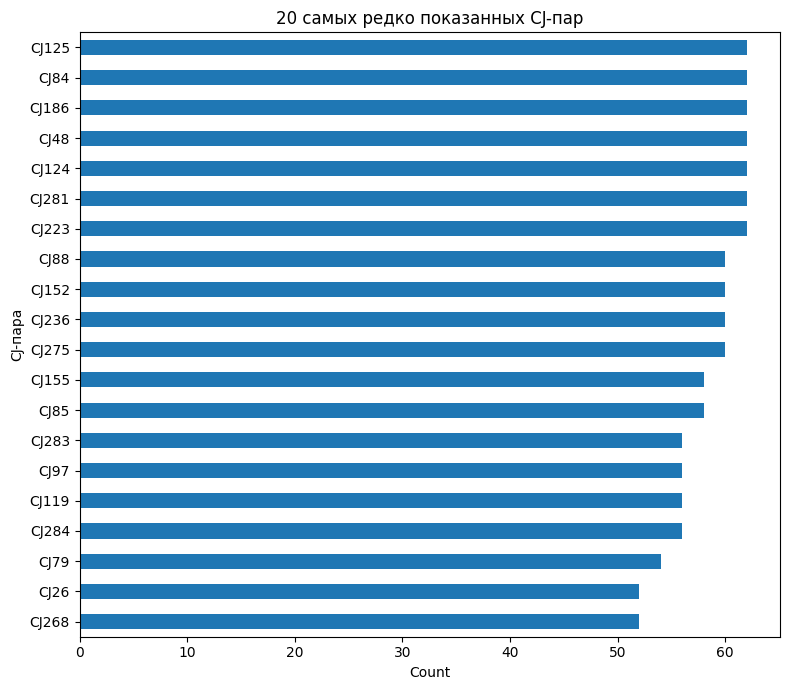

In [4]:
counts = reg_df["cj_var"].value_counts()

rare = counts.sort_values().head(20)
common = counts.sort_values(ascending=False).head(20).sort_values()

plt.figure(figsize=(8, 7))

rare.plot(kind="barh")

plt.xlabel("Count")
plt.ylabel("CJ-пара")
plt.title("20 самых редко показанных CJ-пар")

plt.tight_layout()
plt.show()

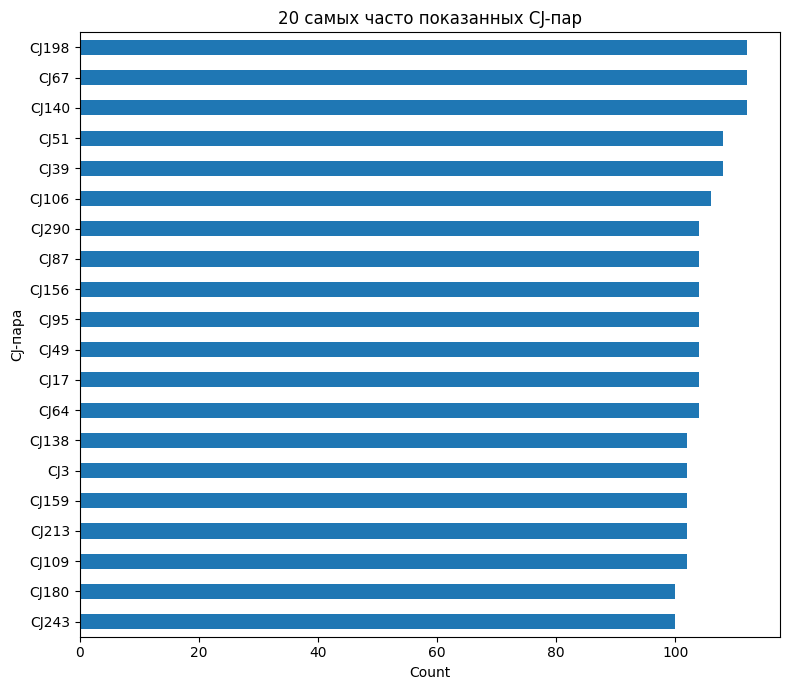

In [5]:
plt.figure(figsize=(8, 7))

common.plot(kind="barh")

plt.xlabel("Count")
plt.ylabel("CJ-пара")
plt.title("20 самых часто показанных CJ-пар")

plt.tight_layout()
plt.show()

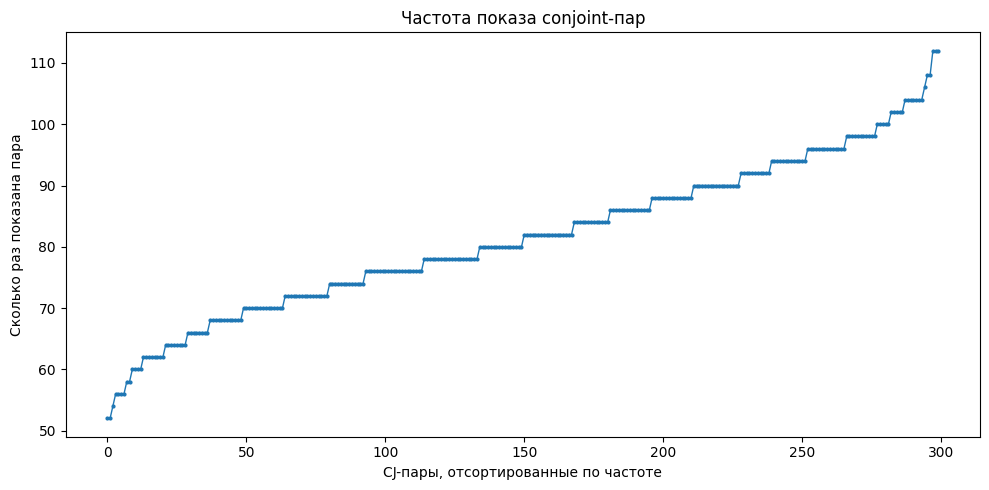

In [6]:
counts = reg_df["cj_var"].value_counts().sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.plot(counts.values, marker="o", markersize=2, linewidth=1)

plt.xlabel("CJ-пары, отсортированные по частоте")
plt.ylabel("Сколько раз показана пара")
plt.title("Частота показа conjoint-пар")

plt.tight_layout()
plt.show()

In [134]:
ATTRS = ["region", "motivation", "education", "employer", "gender", "age", "occupation", "language", "politics", "appearance"]

POSITION_COL = "candidate"  

balance_df = reg_df.copy()

for col in ATTRS + [POSITION_COL]:

    balance_df[col] = balance_df[col].astype(str)

In [138]:
ATTRS = [
    "region", "motivation", "education", "employer", "gender",
    "age", "occupation", "language", "politics", "appearance"
]

POSITION_COL = "candidate"

rows = []

for attr in ATTRS:
    tab = pd.crosstab(reg_df[attr], reg_df[POSITION_COL])
    chi2, p, df_chi, expected = chi2_contingency(tab)
    
    rows.append({
        "Атрибут": attr,
        "Chi2": round(chi2, 3),
        "df": df_chi,
        "p-value": round(p, 3)
    })

balance_by_position = pd.DataFrame(rows)
balance_by_position

,Атрибут,Chi2,df,p-value
0,region,4124.666,6,0.0
1,motivation,500.619,3,0.0
2,education,155.305,2,0.0
3,employer,96.244,1,0.0
4,gender,40.900,1,0.0
5,age,39.270,2,0.0
6,occupation,68.411,3,0.0
7,language,45.439,1,0.0
8,politics,336.215,3,0.0
9,appearance,102.103,1,0.0


In [133]:
reg_df["candidate"].value_counts(dropna=False)

candidate
1    12225
2    12225
Name: count, dtype: int64

In [139]:
pd.crosstab(

    reg_df["region"],

    reg_df["candidate"],

    margins=True

)

candidate,1,2,All
region,,,
"Африка (Кения, Нигерия, ЮАР)",2507,1812,4319
"Восточная Азия (Китай, Монголия, Южная Корея)",3545,683,4228
"Восточная Европа (Беларусь, Молдова, Украина)",1167,2087,3254
"Западная Европа (Германия, Италия, Франция)",390,1990,2380
"Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)",1945,1195,3140
"Юго-Восточная Европа (Болгария, Венгрия, Сербия)",917,2122,3039
"Южный Кавказ (Азербайджан, Армения, Грузия)",1754,2336,4090
All,12225,12225,24450


In [140]:
pd.crosstab(reg_df["profile"], reg_df["candidate"])

candidate,1,2
profile,,
R1M1Ed1Em1G2A7O3L1P4Ap2,0,45
R1M1Ed1Em2G2A2O3L1P2Ap2,0,42
R1M1Ed1Em2G2A5O2L1P3Ap2,0,40
R1M1Ed2Em1G1A8O3L1P1Ap1,44,0
R1M1Ed2Em1G1A9O4L2P2Ap1,0,37
...,...,...
R7M4Ed3Em2G2A5O2L2P2Ap1,39,0
R7M4Ed3Em2G2A7O4L2P3Ap2,0,41
R7M4Ed3Em2G2A8O2L2P3Ap2,0,48


In [141]:
reg_df["ap_from_profile"] = reg_df["profile"].str.extract(r"(Ap\d+)$")[0]

pd.crosstab(reg_df["ap_from_profile"], reg_df["candidate"])

candidate,1,2
ap_from_profile,,
Ap1,5698,6489
Ap2,6527,5736


In [142]:
model_main_candidate = smf.ols(

    "outcome ~ C(region) + C(motivation) + C(education) + C(employer) + "

    "C(gender) + C(age) + C(occupation) + C(language) + C(politics) + "

    "C(appearance) + C(candidate)",

    data=reg_df

).fit(

    cov_type="cluster",

    cov_kwds={"groups": reg_df["respondent_id"]}

)

model_main_candidate.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     37.82
Date:                Thu, 14 May 2026   Prob (F-statistic):          5.36e-115
Time:                        03:34:27   Log-Likelihood:                -17348.
No. Observations:               24450   AIC:                         3.475e+04
Df Residuals:                   24425   BIC:                         3.495e+04
Df Model:                          24                                         
Covariance Type:              cluster                                         
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.5682      0.017     33.543      0.000       0.535       0.601
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.0688      0.010      6.605      0.000       0.048       0.089
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.0522      0.012      4.472      0.000       0.029       0.075
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.0904      0.011      8.422      0.000       0.069       0.111
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0333      0.010     -3.220      0.001      -0.054      -0.013
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.0697      0.011      6.123      0.000       0.047       0.092
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0273      0.011     -2.524      0.012      -0.049      -0.006
C(motivation)[T.Бегство от политических преследований]                           -0.0623      0.008     -7.488      0.000      -0.079      -0.046
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0360      0.009      4.227      0.000       0.019       0.053
C(motivation)[T.Поиск работы]                                                    -0.0053      0.009     -0.618      0.536      -0.022       0.012
C(education)[T.Среднее (школа)]                                                  -0.0352      0.006     -5.608      0.000      -0.048      -0.023
C(education)[T.Среднее специальное (колледж)]                                    -0.0027      0.007     -0.410      0.682      -0.016       0.010
C(employer)[T.Небольшая частная компания]                                         0.0013      0.006      0.225      0.822      -0.010       0.013
C(gender)[T.Мужчина]                                                             -0.0573      0.006     -8.942      0.000      -0.070      -0.045
C(age)[T.45]                                                                     -0.0264      0.008     -3.165      0.002      -0.043      -0.010
C(age)[T.60]                                                                     -0.0503      0.009     -5.401      0.000      -0.068      -0.032
C(occupation)[T.Программист]                                                     -0.0153      0.012     -1.288      0.198      -0.039       0.008
C(occupation)[T.Строитель]                                                       -0.0439      0.012     -3.664      0.000      -0.067      -0.020
C(occupation)[T.С

In [143]:
from scipy.stats import chi2_contingency
import pandas as pd

ATTRS = [
    "region", "motivation", "education", "employer", "gender",
    "age", "occupation", "language", "politics", "appearance"
]

rows = []

for attr in ATTRS:
    tab = pd.crosstab(reg_df[attr], reg_df["candidate"])
    chi2, p, df_chi, expected = chi2_contingency(tab)
    
    rows.append({
        "Атрибут": attr,
        "Chi2": round(chi2, 3),
        "df": df_chi,
        "p-value": round(p, 3)
    })

candidate_balance = pd.DataFrame(rows)
candidate_balance

,Атрибут,Chi2,df,p-value
0,region,4124.666,6,0.0
1,motivation,500.619,3,0.0
2,education,155.305,2,0.0
3,employer,96.244,1,0.0
4,gender,40.900,1,0.0
5,age,39.270,2,0.0
6,occupation,68.411,3,0.0
7,language,45.439,1,0.0
8,politics,336.215,3,0.0
9,appearance,102.103,1,0.0


In [144]:
ATTRS = [
    "region", "motivation", "education", "employer", "gender",
    "age", "occupation", "language", "politics", "appearance"
]

POSITION_COL = "candidate"

rows = []

for attr in ATTRS:
    tab = pd.crosstab(reg_df[attr], reg_df[POSITION_COL])
    
    chi2, p, df_chi, expected = chi2_contingency(tab)
    
    prop = pd.crosstab(
        reg_df[attr],
        reg_df[POSITION_COL],
        normalize="columns"
    )
    
    # максимальная абсолютная разница долей между candidate 1 и candidate 2
    max_abs_diff = (prop[1] - prop[2]).abs().max()
    
    # Cramer's V
    n = tab.values.sum()
    r, k = tab.shape
    cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))
    
    rows.append({
        "Атрибут": attr,
        "Chi2": round(chi2, 3),
        "df": df_chi,
        "p-value": round(p, 4),
        "max |diff|": round(max_abs_diff, 3),
        "Cramer's V": round(cramers_v, 3)
    })

balance_effect_size = pd.DataFrame(rows)
balance_effect_size

,Атрибут,Chi2,df,p-value,max |diff|,Cramer's V
0,region,4124.666,6,0.0,0.234,0.411
1,motivation,500.619,3,0.0,0.113,0.143
2,education,155.305,2,0.0,0.073,0.080
3,employer,96.244,1,0.0,0.063,0.063
4,gender,40.900,1,0.0,0.041,0.041
5,age,39.270,2,0.0,0.036,0.040
6,occupation,68.411,3,0.0,0.026,0.053
7,language,45.439,1,0.0,0.043,0.043
8,politics,336.215,3,0.0,0.086,0.117
9,appearance,102.103,1,0.0,0.065,0.065


# Сравнение средних

In [7]:
factor = "occupation"

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / (mean_table["count"] ** 0.5)
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]

mean_table = mean_table.sort_values("mean")

mean_table

,occupation,mean,count,std,se,ci_low,ci_high
3,Сфера услуг (общепит),0.472211,7575,0.499260,0.005736,0.460968,0.483454
2,Строитель,0.491584,7486,0.499963,0.005778,0.480258,0.502910
1,Программист,0.525493,7355,0.499384,0.005823,0.514080,0.536906
0,Врач,0.542281,2034,0.498332,0.011050,0.520624,0.563938


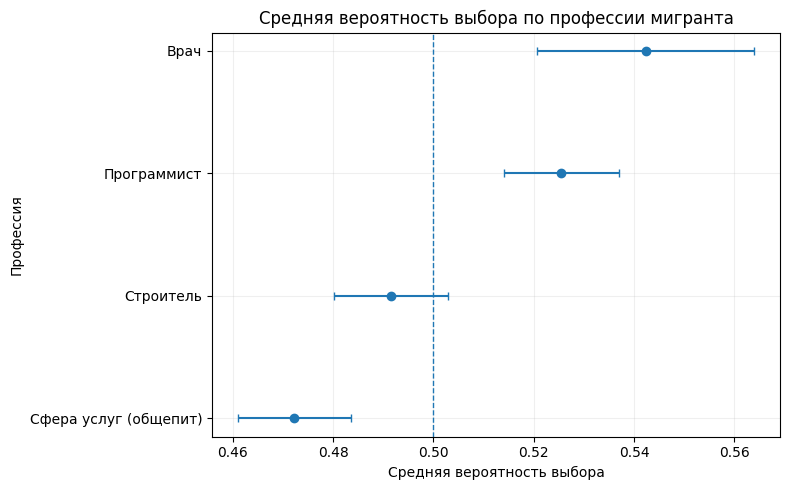

In [8]:
plt.figure(figsize=(8, 5))

plt.errorbar(mean_table["mean"], mean_table[factor],xerr=[mean_table["mean"] - mean_table["ci_low"], mean_table["ci_high"] - mean_table["mean"]],
    fmt="o",
    capsize=3
)

plt.axvline(0.5, linestyle="--", linewidth=1)

plt.xlabel("Средняя вероятность выбора")
plt.ylabel("Профессия")
plt.title("Средняя вероятность выбора по профессии мигранта")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [9]:
factor = "motivation"

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / (mean_table["count"] ** 0.5)
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]

mean_table = mean_table.sort_values("mean")

mean_table

,motivation,mean,count,std,se,ci_low,ci_high
1,Бегство от политических преследований,0.456345,6265,0.498130,0.006293,0.444010,0.468680
3,Поиск работы,0.498252,6292,0.500037,0.006304,0.485896,0.510607
0,Бегство от вооружённого конфликта,0.512468,5454,0.499890,0.006769,0.499201,0.525735
2,"Воссоединение с супругом(ой), ранее приехавшим...",0.533623,6439,0.498907,0.006217,0.521437,0.545809


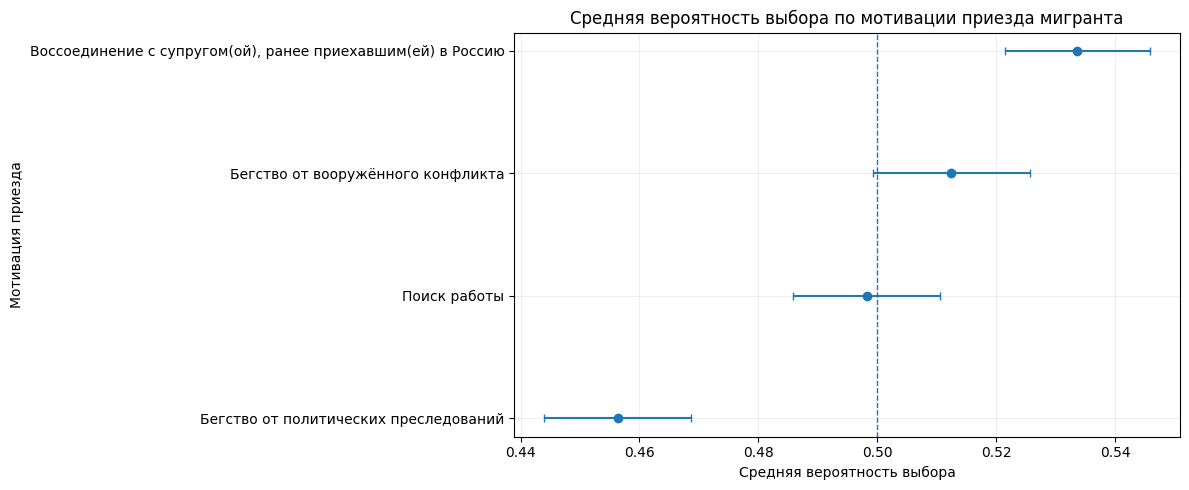

In [10]:
plt.figure(figsize=(12, 5))

plt.errorbar(mean_table["mean"], mean_table[factor],xerr=[mean_table["mean"] - mean_table["ci_low"], mean_table["ci_high"] - mean_table["mean"]],
    fmt="o",
    capsize=3)

plt.axvline(0.5, linestyle="--", linewidth=1)

plt.xlabel("Средняя вероятность выбора")
plt.ylabel("Мотивация приезда")
plt.title("Средняя вероятность выбора по мотивации приезда мигранта")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [11]:
factor = "region"
mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / (mean_table["count"] ** 0.5)
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]

mean_table = mean_table.sort_values("mean")

mean_table

,region,mean,count,std,se,ci_low,ci_high
6,"Южный Кавказ (Азербайджан, Армения, Грузия)",0.451345,4090,0.497688,0.007782,0.436092,0.466598
4,"Средняя Азия (Кыргызстан, Таджикистан, Узбекис...",0.457962,3140,0.498309,0.008893,0.440532,0.475391
0,"Африка (Кения, Нигерия, ЮАР)",0.468395,4319,0.499058,0.007594,0.453512,0.483279
2,"Восточная Европа (Беларусь, Молдова, Украина)",0.522741,3254,0.499559,0.008757,0.505577,0.539906
5,"Юго-Восточная Европа (Болгария, Венгрия, Сербия)",0.527147,3039,0.499345,0.009058,0.509393,0.544901
1,"Восточная Азия (Китай, Монголия, Южная Корея)",0.536424,4228,0.498731,0.007670,0.521391,0.551457
3,"Западная Европа (Германия, Италия, Франция)",0.565966,2380,0.495733,0.010162,0.546050,0.585883


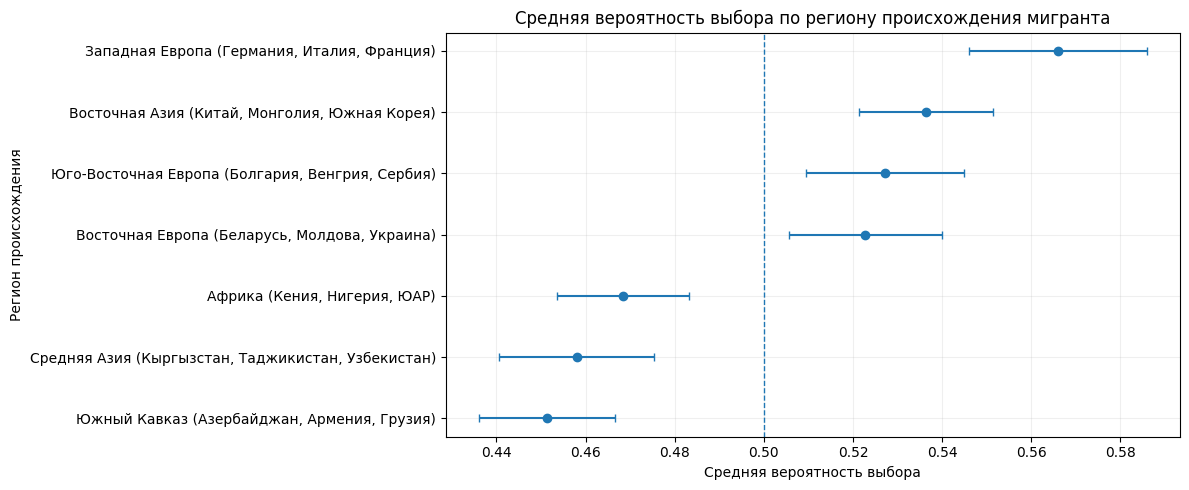

In [12]:
plt.figure(figsize=(12, 5))

plt.errorbar(mean_table["mean"], mean_table[factor],xerr=[mean_table["mean"] - mean_table["ci_low"], mean_table["ci_high"] - mean_table["mean"]],
    fmt="o",
    capsize=3)

plt.axvline(0.5, linestyle="--", linewidth=1)

plt.xlabel("Средняя вероятность выбора")
plt.ylabel("Регион происхождения")
plt.title("Средняя вероятность выбора по региону происхождения мигранта")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
factor = "politics"
mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / (mean_table["count"] ** 0.5)
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]

mean_table = mean_table.sort_values("mean")

mean_table

,politics,mean,count,std,se,ci_low,ci_high
3,Страна присоединилась к санкциям против России,0.469223,5946,0.499094,0.006472,0.456537,0.481909
1,Страна обычно голосует вместе с США в Генассам...,0.498745,7174,0.500033,0.005904,0.487174,0.510317
0,Страна обычно голосует вместе с Россией в Гена...,0.514540,7084,0.499824,0.005939,0.502900,0.526179
2,Страна помогает России обходить санкции (парал...,0.520961,4246,0.499619,0.007667,0.505933,0.535989


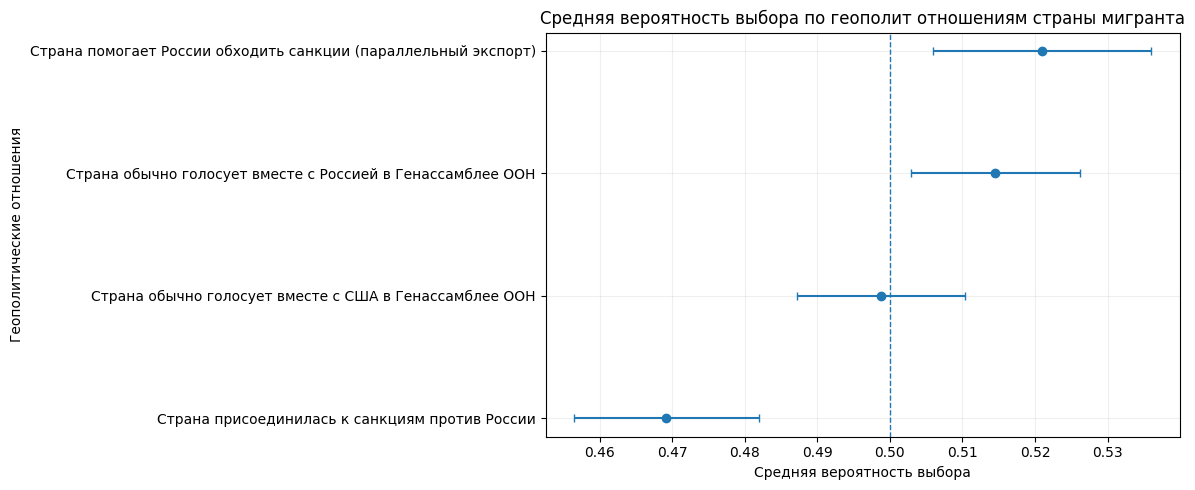

In [14]:
plt.figure(figsize=(12, 5))

plt.errorbar(mean_table["mean"], mean_table[factor],xerr=[mean_table["mean"] - mean_table["ci_low"], mean_table["ci_high"] - mean_table["mean"]],
    fmt="o",
    capsize=3)

plt.axvline(0.5, linestyle="--", linewidth=1)

plt.xlabel("Средняя вероятность выбора")
plt.ylabel("Геополитические отношения")
plt.title("Средняя вероятность выбора по геополит отношениям страны мигранта")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [15]:
factor = "appearance"
mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / (mean_table["count"] ** 0.5)
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]

mean_table = mean_table.sort_values("mean")

mean_table

,appearance,mean,count,std,se,ci_low,ci_high
1,В повседневной жизни носит традиционную национ...,0.476229,12263,0.499455,0.004510,0.467389,0.485069
0,В повседневной жизни носит обычную светскую од...,0.523919,12187,0.499448,0.004524,0.515051,0.532786


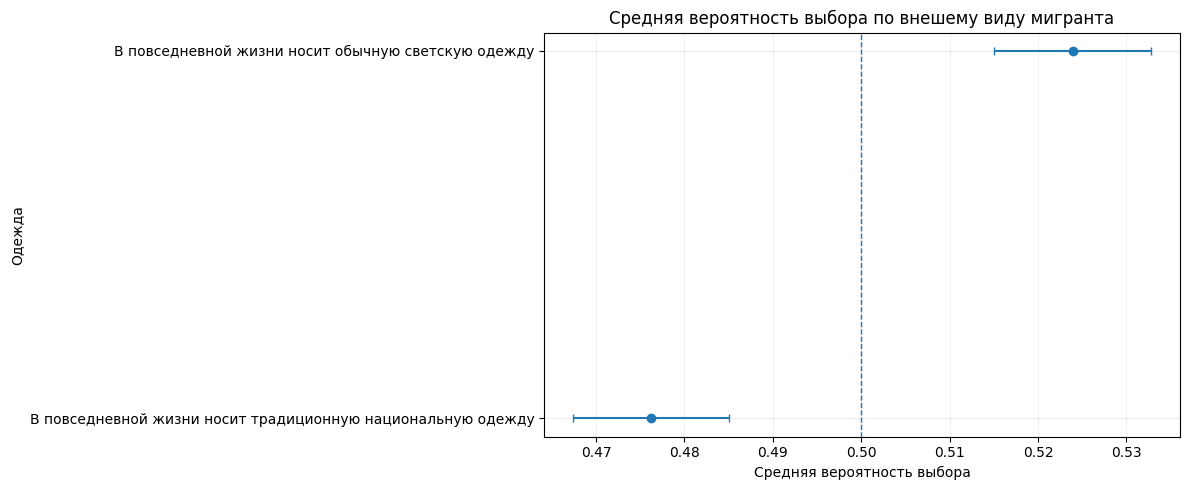

In [16]:
plt.figure(figsize=(12, 5))

plt.errorbar(mean_table["mean"], mean_table[factor],xerr=[mean_table["mean"] - mean_table["ci_low"], mean_table["ci_high"] - mean_table["mean"]],
    fmt="o",
    capsize=3)

plt.axvline(0.5, linestyle="--", linewidth=1)

plt.xlabel("Средняя вероятность выбора")
plt.ylabel("Одежда")
plt.title("Средняя вероятность выбора по внешему виду мигранта")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
factor = "education"
mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / (mean_table["count"] ** 0.5)
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]

mean_table = mean_table.sort_values("mean")

mean_table

,education,mean,count,std,se,ci_low,ci_high
1,Среднее (школа),0.471062,7447,0.499195,0.005785,0.459724,0.482400
2,Среднее специальное (колледж),0.500133,7504,0.500033,0.005772,0.488819,0.511447
0,Высшее (университет),0.522581,9499,0.499516,0.005125,0.512536,0.532627


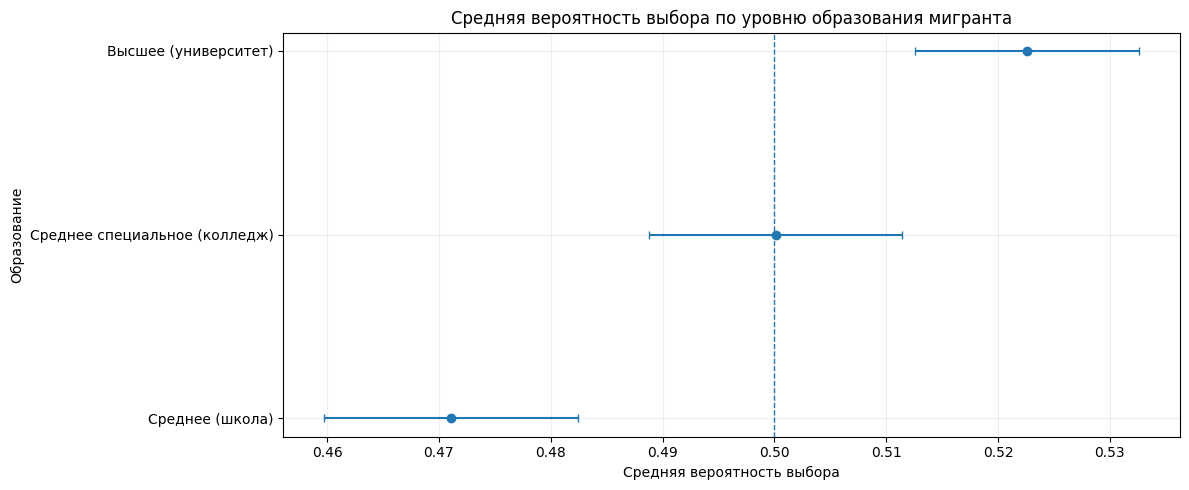

In [18]:
plt.figure(figsize=(12, 5))

plt.errorbar(mean_table["mean"], mean_table[factor],xerr=[mean_table["mean"] - mean_table["ci_low"], mean_table["ci_high"] - mean_table["mean"]],
    fmt="o",
    capsize=3)

plt.axvline(0.5, linestyle="--", linewidth=1)

plt.xlabel("Средняя вероятность выбора")
plt.ylabel("Образование")
plt.title("Средняя вероятность выбора по уровню образования мигранта")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [19]:
factor = "language"
mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / (mean_table["count"] ** 0.5)
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]

mean_table = mean_table.sort_values("mean")

mean_table

,language,mean,count,std,se,ci_low,ci_high
0,Говорит плохо,0.458588,12122,0.498303,0.004526,0.449717,0.467458
1,Говорит свободно,0.540720,12328,0.498359,0.004488,0.531923,0.549518


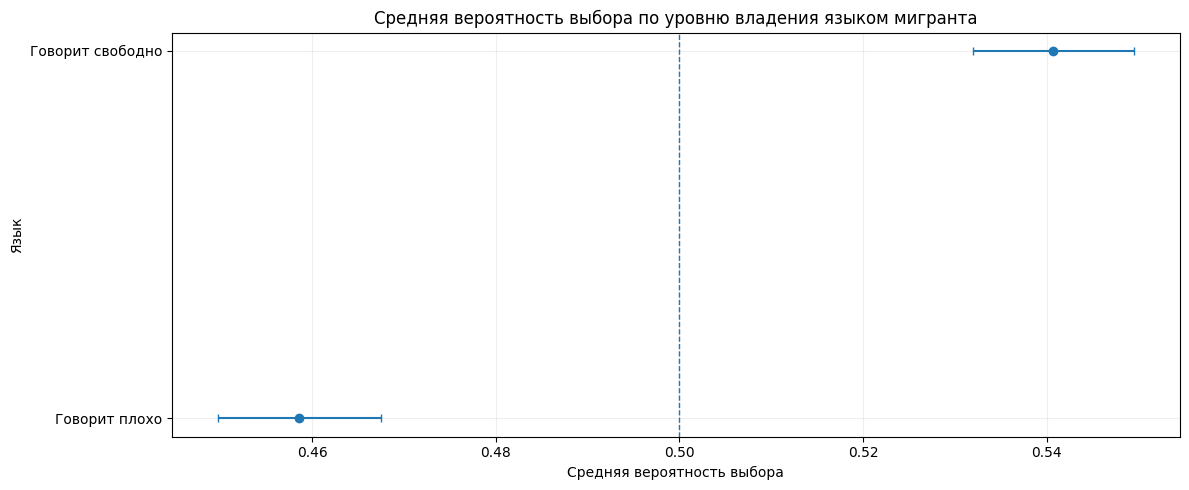

In [20]:
plt.figure(figsize=(12, 5))

plt.errorbar(mean_table["mean"], mean_table[factor],xerr=[mean_table["mean"] - mean_table["ci_low"], mean_table["ci_high"] - mean_table["mean"]],
    fmt="o",
    capsize=3)

plt.axvline(0.5, linestyle="--", linewidth=1)

plt.xlabel("Средняя вероятность выбора")
plt.ylabel("Язык")
plt.title("Средняя вероятность выбора по уровню владения языком мигранта")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Графики средних без модели и с моделью

In [21]:
factor = "occupation"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [22]:

formula = ("outcome ~ C(occupation) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [23]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

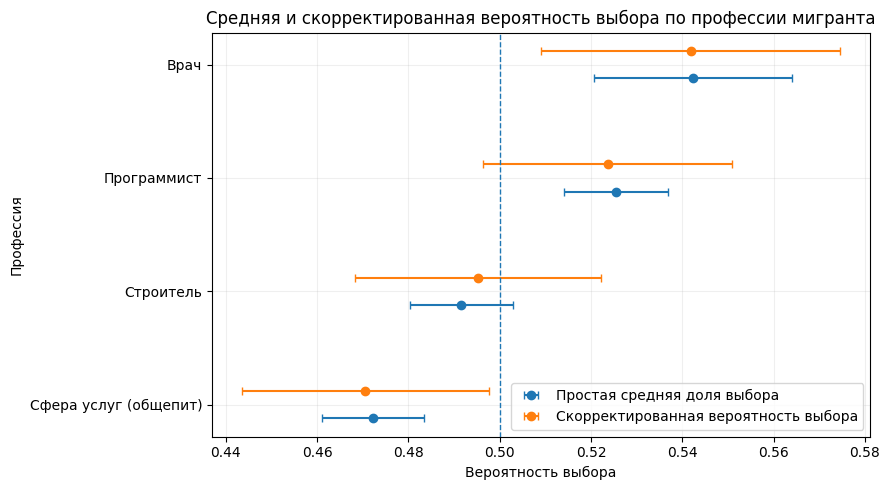

In [24]:
plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 5))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(sub["mean"],y,
        xerr=[
            sub["mean"] - sub["ci_low"],
            sub["ci_high"] - sub["mean"]
        ],
        fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(order)

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Профессия")
ax.set_title("Средняя и скорректированная вероятность выбора по профессии мигранта")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("occupation_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

In [25]:
factor = "region"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())

mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [26]:
formula = ("outcome ~ C(region) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [27]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

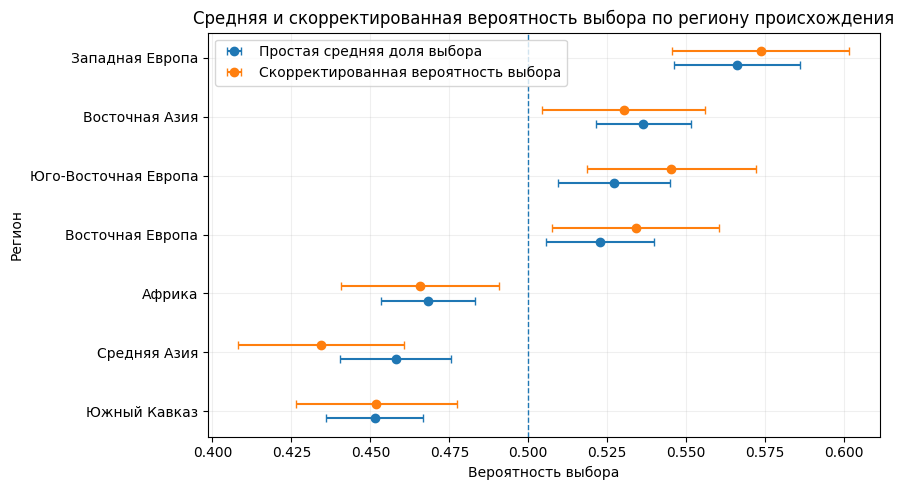

In [28]:
region_short = {
    "Восточная Европа (Беларусь, Молдова, Украина)": "Восточная Европа",
    "Юго-Восточная Европа (Болгария, Венгрия, Сербия)": "Юго-Восточная Европа",
    "Западная Европа (Германия, Италия, Франция)": "Западная Европа",
    "Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)": "Средняя Азия",
    "Восточная Азия (Китай, Монголия, Южная Корея)": "Восточная Азия",
    "Южный Кавказ (Азербайджан, Армения, Грузия)": "Южный Кавказ",
    "Африка (Кения, Нигерия, ЮАР)": "Африка"
}

order_labels = [region_short.get(x, x) for x in order]

plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 5))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(
        sub["mean"], y,
        xerr=[sub["mean"] - sub["ci_low"],
            sub["ci_high"] - sub["mean"]
        ],
        fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(order_labels)

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Регион")
ax.set_title("Средняя и скорректированная вероятность выбора по региону происхождения")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("region_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

In [29]:
factor = "language"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [30]:
formula = ("outcome ~ C(language) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [31]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

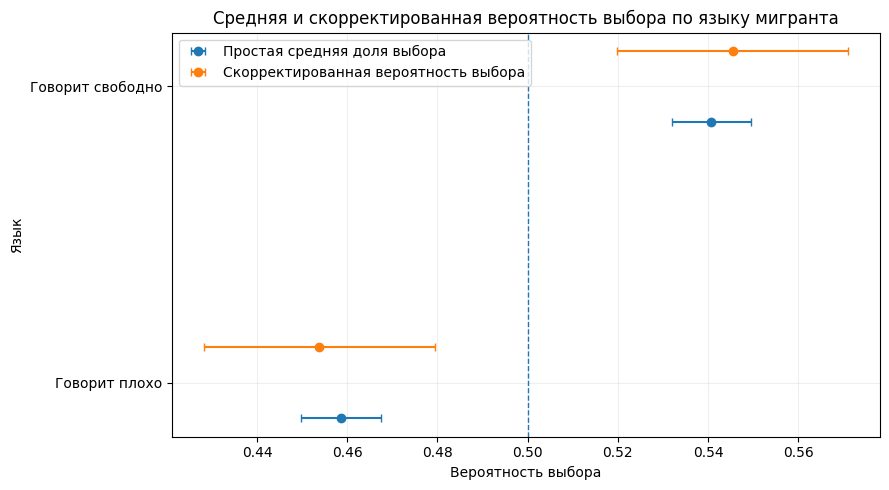

In [32]:
plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 5))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(sub["mean"],y,
        xerr=[
            sub["mean"] - sub["ci_low"],
            sub["ci_high"] - sub["mean"]
        ],
        fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(order)

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Язык")
ax.set_title("Средняя и скорректированная вероятность выбора по языку мигранта")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("language_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

In [33]:
factor = "motivation"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [34]:
formula = ("outcome ~ C(motivation) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [35]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

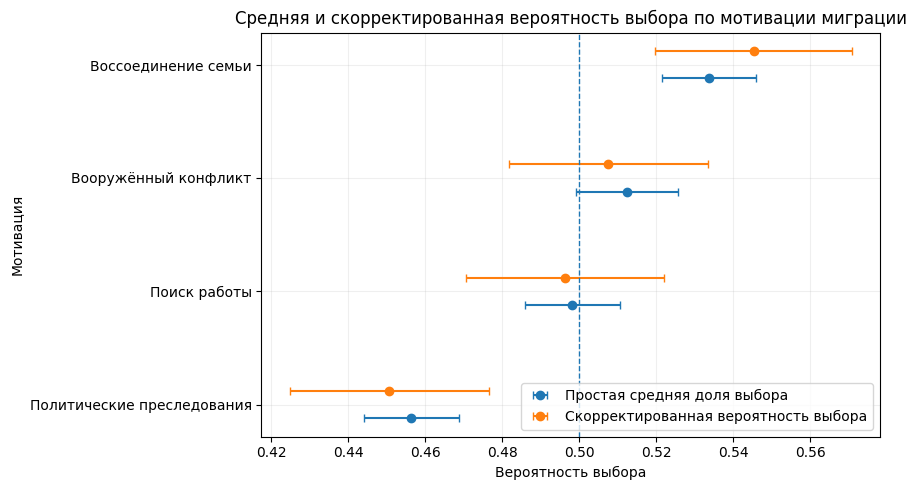

In [36]:
motivation_short = {"Поиск работы": "Поиск работы", "Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию": "Воссоединение семьи",
    "Учёба": "Учёба","Бегство от вооружённого конфликта": "Вооружённый конфликт",
    "Бегство от политических преследований": "Политические преследования",
    "Переезд из-за политической и международной нестабильности": "Политическая нестабильность"}

order_labels = [motivation_short.get(x, x) for x in order]

plot_df["type"] = plot_df["type"].replace({"Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 5))

labels_offsets = {"Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(sub["mean"], y, xerr=[
            sub["mean"] - sub["ci_low"],
            sub["ci_high"] - sub["mean"]], fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(order_labels)

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Мотивация")
ax.set_title("Средняя и скорректированная вероятность выбора по мотивации миграции")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("motivation_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

In [37]:
factor = "education"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [38]:
formula = ("outcome ~ C(education) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [39]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

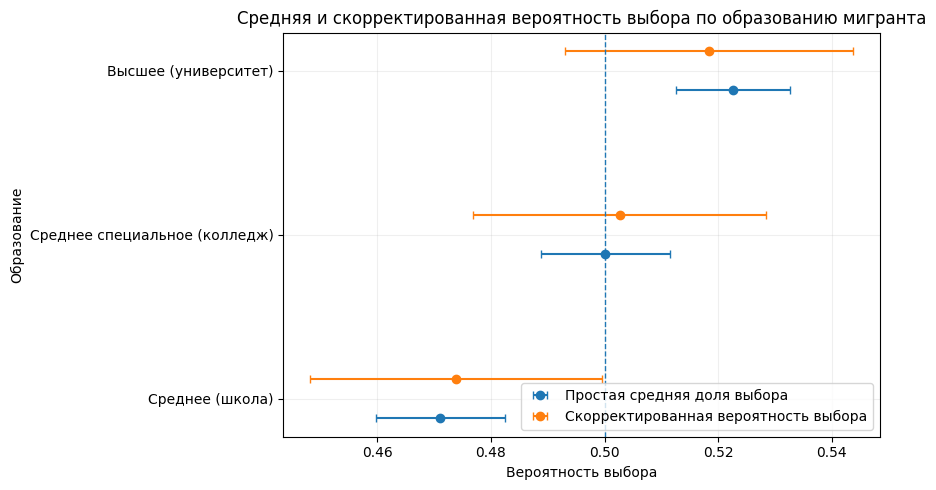

In [40]:
plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 5))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(sub["mean"],y,
        xerr=[
            sub["mean"] - sub["ci_low"],
            sub["ci_high"] - sub["mean"]
        ],
        fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(order)

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Образование")
ax.set_title("Средняя и скорректированная вероятность выбора по образованию мигранта")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("educ_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

In [41]:
factor = "employer"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [42]:
formula = ("outcome ~ C(employer) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [43]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

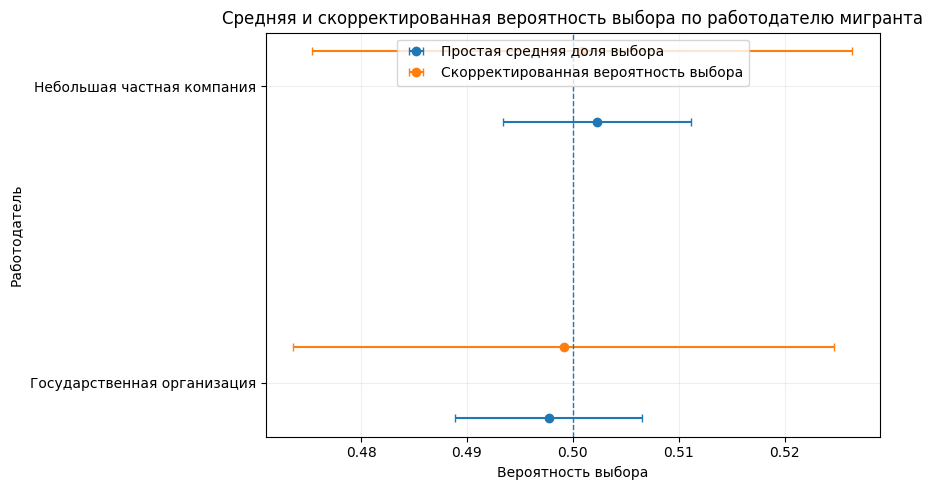

In [44]:
plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 5))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(sub["mean"],y,
        xerr=[
            sub["mean"] - sub["ci_low"],
            sub["ci_high"] - sub["mean"]
        ],
        fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(order)

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Работодатель")
ax.set_title("Средняя и скорректированная вероятность выбора по работодателю мигранта")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig('empolyer_mean_vs_regression.png', dpi=1600, bbox_inches="tight")
plt.show()

In [45]:
factor = "gender"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [46]:
formula = ("outcome ~ C(gender) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [47]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

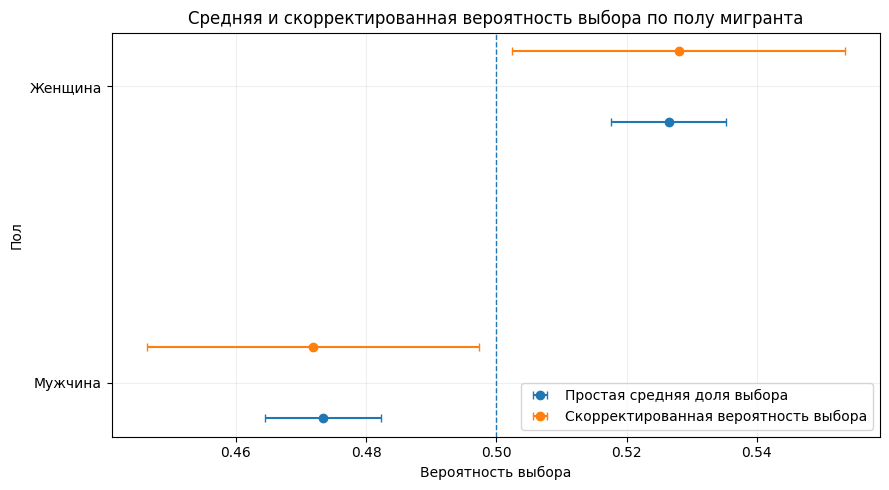

In [48]:
plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 5))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(sub["mean"],y,
        xerr=[
            sub["mean"] - sub["ci_low"],
            sub["ci_high"] - sub["mean"]
        ],
        fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(order)

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Пол")
ax.set_title("Средняя и скорректированная вероятность выбора по полу мигранта")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig('gender_mean_vs_regression.png', dpi=1600, bbox_inches="tight")
plt.show()

In [49]:
factor = "age"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [50]:
formula = ("outcome ~ C(age) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [51]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

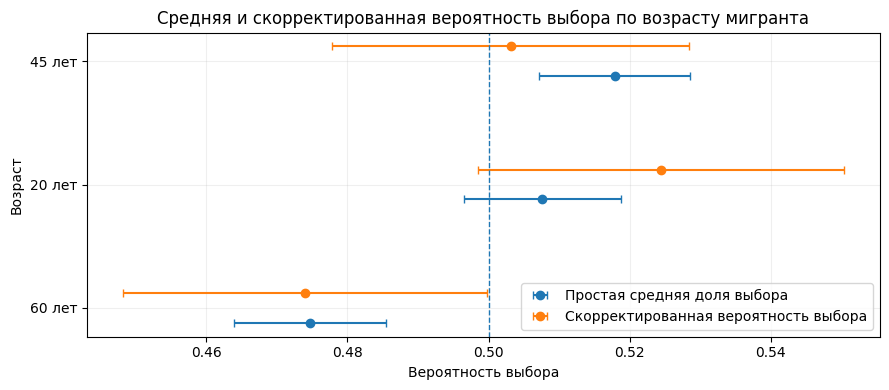

In [52]:
factor = "age"

order = [str(x) for x in order]
plot_df[factor] = plot_df[factor].astype(str)

plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12

fig, ax = plt.subplots(figsize=(9, 4))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    
    y = y_positions + off
    
    ax.errorbar(sub["mean"],y, xerr=[sub["mean"] - sub["ci_low"],sub["ci_high"] - sub["mean"]
        ],
        fmt="o",
        capsize=3,
        label=label
    )

ax.axvline(0.5, linestyle="--", linewidth=1)

ax.set_yticks(y_positions)
ax.set_yticklabels([f"{x} лет" for x in order])

ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Возраст")
ax.set_title("Средняя и скорректированная вероятность выбора по возрасту мигранта")

ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("age_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

In [53]:
factor = "politics"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [54]:
formula = ("outcome ~ C(politics) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [55]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

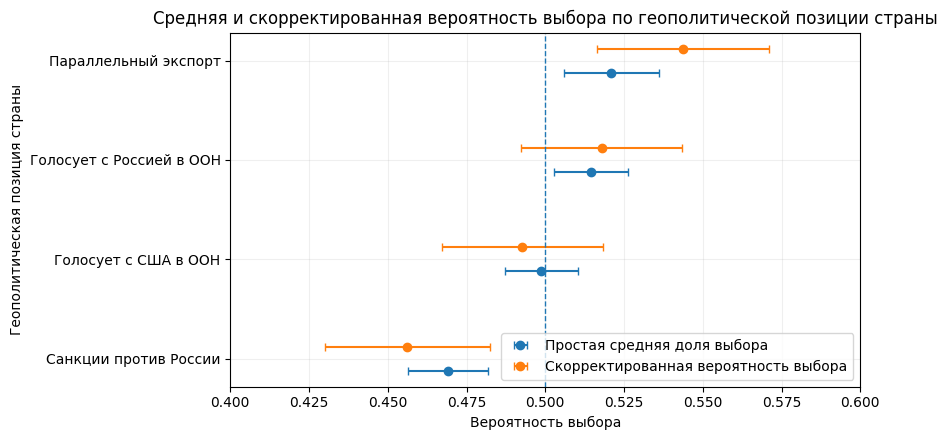

In [56]:
politics_short = {
    "Страна присоединилась к санкциям против России": "Санкции против России",
    "Страна обычно голосует вместе с Россией в Генассамблее ООН": "Голосует с Россией в ООН",
    "Страна обычно голосует вместе с США в Генассамблее ООН": "Голосует с США в ООН",
    "Страна помогает России обходить санкции (параллельный экспорт)": "Параллельный экспорт"
}

order = [str(x) for x in order]
plot_df[factor] = plot_df[factor].astype(str)
order_labels = [politics_short.get(x, x) for x in order]

plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12
fig, ax = plt.subplots(figsize=(9, 4.5))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    y = y_positions + off
    ax.errorbar(sub["mean"], y, xerr=[sub["mean"] - sub["ci_low"], sub["ci_high"] - sub["mean"]], fmt="o", capsize=3, label=label)

ax.axvline(0.5, linestyle="--", linewidth=1)
ax.set_xlim(0.4, 0.6)
ax.set_yticks(y_positions)
ax.set_yticklabels(order_labels)
ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Геополитическая позиция страны")
ax.set_title("Средняя и скорректированная вероятность выбора по геополитической позиции страны")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("politics_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

In [57]:
factor = "appearance"

controls = ["region", "motivation", "education", "employer", "gender", "age", "language", "politics", "appearance"]

mean_table = (reg_df.groupby(factor)["outcome"].agg(["mean", "count", "std"]).reset_index())
mean_table["se"] = mean_table["std"] / np.sqrt(mean_table["count"])
mean_table["ci_low"] = mean_table["mean"] - 1.96 * mean_table["se"]
mean_table["ci_high"] = mean_table["mean"] + 1.96 * mean_table["se"]
mean_table["type"] = "Простая средняя доля выбора"

In [58]:
formula = ("outcome ~ C(appearance) + "+ " + ".join([f"C({x})" for x in controls]))

model = smf.ols(formula, data=reg_df).fit(cov_type="cluster",cov_kwds={"groups": reg_df["respondent_id"]})
pred_rows = []

for lvl in reg_df[factor].dropna().unique():
    tmp = reg_df.copy()
    tmp[factor] = lvl
    
    pred = model.get_prediction(tmp)
    sf = pred.summary_frame(alpha=0.05)
    
    pred_rows.append({factor: lvl,
        "mean": sf["mean"].mean(),
        "ci_low": sf["mean_ci_lower"].mean(),
        "ci_high": sf["mean_ci_upper"].mean(),
        "count": tmp.shape[0],
        "type": "Regression-adjusted"})

reg_table = pd.DataFrame(pred_rows)

In [59]:
plot_df = pd.concat([mean_table[[factor, "mean", "ci_low", "ci_high", "type"]], reg_table[[factor, "mean", "ci_low", "ci_high", "type"]]])
order = (mean_table.sort_values("mean")[factor].tolist())

plot_df[factor] = pd.Categorical(plot_df[factor], categories=order, ordered=True)
plot_df = plot_df.sort_values(factor)
plot_df["type"] = plot_df["type"].replace({"Non-model mean": "Простая средняя доля выбора", "Regression-adjusted": "Регрессионно скорректированная вероятность выбора"})

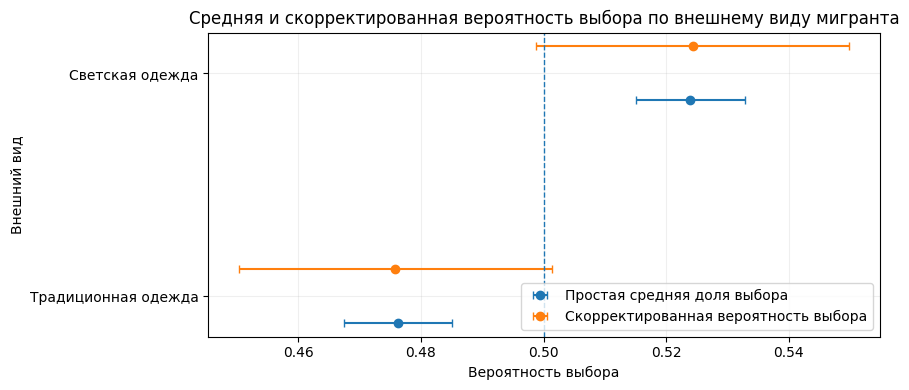

In [60]:
appearance_short = {
    "В повседневной жизни носит обычную светскую одежду": "Светская одежда",
    "В повседневной жизни носит традиционную национальную одежду": "Традиционная одежда"
}

order = [str(x) for x in order]
plot_df[factor] = plot_df[factor].astype(str)
order_labels = [appearance_short.get(x, x) for x in order]

plot_df["type"] = plot_df["type"].replace({
    "Regression-adjusted": "Скорректированная вероятность выбора",
    "Регрессионно скорректированная вероятность выбора": "Скорректированная вероятность выбора"
})

y_positions = np.arange(len(order))
offset = 0.12
fig, ax = plt.subplots(figsize=(9, 4))

labels_offsets = {
    "Простая средняя доля выбора": -offset,
    "Скорректированная вероятность выбора": offset
}

for label, off in labels_offsets.items():
    sub = plot_df[plot_df["type"] == label].copy()
    sub[factor] = sub[factor].astype(str)
    sub = sub.set_index(factor).reindex(order).reset_index()
    y = y_positions + off
    ax.errorbar(sub["mean"], y, xerr=[sub["mean"] - sub["ci_low"], sub["ci_high"] - sub["mean"]], fmt="o", capsize=3, label=label)

ax.axvline(0.5, linestyle="--", linewidth=1)
ax.set_yticks(y_positions)
ax.set_yticklabels(order_labels)
ax.set_xlabel("Вероятность выбора")
ax.set_ylabel("Внешний вид")
ax.set_title("Средняя и скорректированная вероятность выбора по внешнему виду мигранта")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("appearance_mean_vs_regression.png", dpi=1600, bbox_inches="tight")
plt.show()

# Характеристики респондентов

In [61]:
reg_df['Age_resp']

0        44
1        44
2        44
3        44
4        44
         ..
24445    19
24446    19
24447    19
24448    19
24449    19
Name: Age_resp, Length: 24450, dtype: int64

# LPM по гипотезам (main AMCE)

### 1. Без ковариат

In [62]:
model_main = smf.ols("outcome ~ C(region) + C(motivation)+ C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)", data=reg_df).fit(cov_type="cluster",
    cov_kwds={"groups": reg_df["respondent_id"]}
)
model_main.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     39.34
Date:                Wed, 13 May 2026   Prob (F-statistic):          2.29e-115
Time:                        02:06:14   Log-Likelihood:                -17357.
No. Observations:               24450   AIC:                         3.476e+04
Df Residuals:                   24426   BIC:                         3.496e+04
Df Model:                          23                                         
Covariance Type:              cluster                                         
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.5841      0.016     37.308      0.000       0.553       0.615
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.0606      0.010      5.806      0.000       0.040       0.081
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.0578      0.012      4.803      0.000       0.034       0.081
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.1022      0.012      8.867      0.000       0.080       0.125
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0350      0.010     -3.367      0.001      -0.055      -0.015
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.0772      0.012      6.594      0.000       0.054       0.100
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0233      0.011     -2.141      0.032      -0.045      -0.002
C(motivation)[T.Бегство от политических преследований]                           -0.0599      0.008     -7.158      0.000      -0.076      -0.044
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0345      0.009      4.042      0.000       0.018       0.051
C(motivation)[T.Поиск работы]                                                    -0.0085      0.009     -0.979      0.327      -0.025       0.008
C(education)[T.Среднее (школа)]                                                  -0.0367      0.006     -5.766      0.000      -0.049      -0.024
C(education)[T.Среднее специальное (колледж)]                                    -0.0039      0.007     -0.576      0.564      -0.017       0.009
C(employer)[T.Небольшая частная компания]                                         0.0028      0.006      0.474      0.635      -0.009       0.014
C(gender)[T.Мужчина]                                                             -0.0581      0.006     -9.053      0.000      -0.071      -0.046
C(age)[T.45]                                                                     -0.0263      0.008     -3.155      0.002      -0.043      -0.010
C(age)[T.60]                                                                     -0.0504      0.009     -5.414      0.000      -0.069      -0.032
C(occupation)[T.Программист]                                                     -0.0182      0.012     -1.536      0.124      -0.041       0.005
C(occupation)[T.Строитель]                                                       -0.0466      0.012     -3.915      0.000      -0.070      -0.023
C(occupation)[T.С

# LPM по гипотезам (subgroup AMCE)

### 1. Аскриптивно-этническая и гражданская идентичности

In [65]:
model_identity = smf.ols("outcome ~ C(region) * identity_ethnic_index_c + C(region) * identity_civic_index_c + C(motivation)+ C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)", data=reg_df).fit(
    cov_type="cluster", cov_kwds={"groups": reg_df["respondent_id"]})
model_identity.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     24.73
Date:                Wed, 13 May 2026   Prob (F-statistic):          4.67e-108
Time:                        02:06:59   Log-Likelihood:                -17351.
No. Observations:               24450   AIC:                         3.478e+04
Df Residuals:                   24412   BIC:                         3.509e+04
Df Model:                          37                                         
Covariance Type:              cluster                                         
===========================================================================================================================================================
                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                   0.5845      0.016     37.298      0.000       0.554       0.615
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                  0.0607      0.010      5.823      0.000       0.040       0.081
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                  0.0578      0.012      4.829      0.000       0.034       0.081
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                    0.1030      0.012      8.900      0.000       0.080       0.126
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                            -0.0349      0.010     -3.360      0.001      -0.055      -0.015
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                               0.0775      0.012      6.640      0.000       0.055       0.100
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                   -0.0229      0.011     -2.108      0.035      -0.044      -0.002
C(motivation)[T.Бегство от политических преследований]                                     -0.0600      0.008     -7.162      0.000      -0.076      -0.044
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                0.0345      0.009      4.034      0.000       0.018       0.051
C(motivation)[T.Поиск работы]                                                              -0.0087      0.009     -1.007      0.314      -0.026       0.008
C(education)[T.Среднее (школа)]                                                            -0.0366      0.006     -5.755      0.000      -0.049      -0.024
C(education)[T.Среднее специальное (колледж)]                                              -0.0038      0.007     -0.571      0.568      -0.017       0.009
C(employer)[T.Небольшая частная компания]                                                   0.0027      0.006      0.466      0.641      -0.009       0.014
C(gender)[T.Мужчина]                                                                       -0.0582      0.006     -9.073      0.000      -0.071      -0.046
C(age)[T.45]                                                                               -0.0261      0.008     -3.124      0.002      -0.043      -0.010
C(age)[T.60]                                                                               -0.0503      0.009     -5.401      0.000      -0.069      -0.032
C(occupation)[T.Программист]                                                               -0.0186      0.012     -1.57

In [66]:
interaction_results = pd.DataFrame({
    "coef": model_identity.params,
    "std_err": model_identity.bse,
    "p_value": model_identity.pvalues,
    "ci_low": model_identity.conf_int()[0],
    "ci_high": model_identity.conf_int()[1]
})

interaction_results = interaction_results[
    interaction_results.index.str.contains(":")
]

interaction_results

,coef,std_err,p_value,ci_low,ci_high
"C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]:identity_ethnic_index_c",-0.002858,0.007163,0.689903,-0.016897,0.011181
"C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]:identity_ethnic_index_c",0.005185,0.007707,0.501115,-0.009921,0.020290
"C(region)[T.Западная Европа (Германия, Италия, Франция)]:identity_ethnic_index_c",-0.005053,0.007725,0.513092,-0.020194,0.010089
"C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]:identity_ethnic_index_c",0.001334,0.007221,0.853434,-0.012818,0.015486
"C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]:identity_ethnic_index_c",0.002338,0.007408,0.752252,-0.012181,0.016857
"C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]:identity_ethnic_index_c",0.000745,0.007548,0.921354,-0.014048,0.015538
"C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]:identity_civic_index_c",0.016457,0.011292,0.145002,-0.005675,0.038588
"C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]:identity_civic_index_c",0.014724,0.012009,0.220189,-0.008814,0.038262
"C(region)[T.Западная Европа (Германия, Италия, Франция)]:identity_civic_index_c",0.000172,0.013099,0.989508,-0.025500,0.025845
"C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]:identity_civic_index_c",0.019564,0.011163,0.079663,-0.002314,0.041443


### 2. Доверие

In [67]:
model_trust = smf.ols("outcome ~ C(politics) * trust_index_c + C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(appearance)", data=reg_df ).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["respondent_id"]}
)

model_trust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     34.06
Date:                Wed, 13 May 2026   Prob (F-statistic):          2.57e-114
Time:                        02:07:10   Log-Likelihood:                -17339.
No. Observations:               24450   AIC:                         3.473e+04
Df Residuals:                   24422   BIC:                         3.496e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
===============================================================================================================================================================
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                       0.5852      0.016     37.370      0.000       0.555       0.616
C(politics)[T.Страна обычно голосует вместе с США в Генассамблее ООН]                          -0.0228      0.007     -3.230      0.001      -0.037      -0.009
C(politics)[T.Страна помогает России обходить санкции (параллельный экспорт)]                   0.0231      0.008      2.858      0.004       0.007       0.039
C(politics)[T.Страна присоединилась к санкциям против России]                                  -0.0605      0.008     -7.575      0.000      -0.076      -0.045
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                      0.0606      0.010      5.819      0.000       0.040       0.081
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                      0.0575      0.012      4.780      0.000       0.034       0.081
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                        0.1024      0.012      8.896      0.000       0.080       0.125
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                -0.0355      0.010     -3.422      0.001      -0.056      -0.015
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                   0.0768      0.012      6.564      0.000       0.054       0.100
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                       -0.0238      0.011     -2.197      0.028      -0.045      -0.003
C(motivation)[T.Бегство от политических преследований]                                         -0.0598      0.008     -7.149      0.000      -0.076      -0.043
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                    0.0344      0.009      4.034      0.000       0.018       0.051
C(motivation)[T.Поиск работы]                                                                  -0.0088      0.009     -1.022      0.307      -0.026       0.008
C(education)[T.Среднее (школа)]                                                                -0.0374      0.006     -5.873      0.000      -0.050      -0.025
C(education)[T.Среднее специальное (колледж)]                                                  -0.0046      0.007     -0.683      0.495      -0.018       0.009
C(employer)[T.Небольшая частная компания]                                                       0.0028      0.006      0.472      0.637      -0.009       0.014
C(gender)[T.Мужчина]                       

In [68]:
interaction_results_trust = pd.DataFrame({
    "coef": model_trust.params,
    "std_err": model_trust.bse,
    "p_value": model_trust.pvalues,
    "ci_low": model_trust.conf_int()[0],
    "ci_high": model_trust.conf_int()[1]
})

interaction_results_trust = interaction_results_trust[
    interaction_results_trust.index.str.contains(":")
]

interaction_results_trust.round(3)

,coef,std_err,p_value,ci_low,ci_high
C(politics)[T.Страна обычно голосует вместе с США в Генассамблее ООН]:trust_index_c,-0.022,0.005,0.000,-0.032,-0.011
C(politics)[T.Страна помогает России обходить санкции (параллельный экспорт)]:trust_index_c,0.006,0.006,0.353,-0.006,0.018
C(politics)[T.Страна присоединилась к санкциям против России]:trust_index_c,-0.034,0.006,0.000,-0.046,-0.023


### 3. Авторитарные установки

In [69]:
model_authoritar = smf.ols("outcome ~ C(region) * authoritar_index_c + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)",
                           data=reg_df).fit(cov_type="cluster", cov_kwds={"groups": reg_df["respondent_id"]})

model_authoritar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     31.51
Date:                Wed, 13 May 2026   Prob (F-statistic):          5.08e-115
Time:                        02:07:17   Log-Likelihood:                -17345.
No. Observations:               24450   AIC:                         3.475e+04
Df Residuals:                   24419   BIC:                         3.500e+04
Df Model:                          30                                         
Covariance Type:              cluster                                         
======================================================================================================================================================
                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                              0.5844      0.016     37.292      0.000       0.554       0.615
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                             0.0605      0.010      5.795      0.000       0.040       0.081
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                             0.0577      0.012      4.804      0.000       0.034       0.081
C(region)[T.Западная Европа (Германия, Италия, Франция)]                               0.1015      0.011      8.833      0.000       0.079       0.124
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                       -0.0355      0.010     -3.418      0.001      -0.056      -0.015
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                          0.0773      0.012      6.594      0.000       0.054       0.100
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                              -0.0232      0.011     -2.139      0.032      -0.045      -0.002
C(motivation)[T.Бегство от политических преследований]                                -0.0600      0.008     -7.171      0.000      -0.076      -0.044
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]           0.0345      0.009      4.042      0.000       0.018       0.051
C(motivation)[T.Поиск работы]                                                         -0.0087      0.009     -1.001      0.317      -0.026       0.008
C(education)[T.Среднее (школа)]                                                       -0.0365      0.006     -5.729      0.000      -0.049      -0.024
C(education)[T.Среднее специальное (колледж)]                                         -0.0036      0.007     -0.533      0.594      -0.017       0.010
C(employer)[T.Небольшая частная компания]                                              0.0026      0.006      0.441      0.659      -0.009       0.014
C(gender)[T.Мужчина]                                                                  -0.0581      0.006     -9.070      0.000      -0.071      -0.046
C(age)[T.45]                                                                          -0.0261      0.008     -3.118      0.002      -0.042      -0.010
C(age)[T.60]                                                                          -0.0502      0.009     -5.399      0.000      -0.068      -0.032
C(occupation)[T.Программист]                                                          -0.0184      0.012     -1.557      0.119      -0.042       0.005
C(occupation)[T.Строитель]                                     

In [70]:
interaction_results_authoritar = pd.DataFrame({
    "coef": model_authoritar.params,
    "std_err": model_authoritar.bse,
    "p_value": model_authoritar.pvalues,
    "ci_low": model_authoritar.conf_int()[0],
    "ci_high": model_authoritar.conf_int()[1]
})

interaction_results_authoritar = interaction_results_authoritar[
    interaction_results_authoritar.index.str.contains(":")
]

interaction_results_authoritar.round(3)

,coef,std_err,p_value,ci_low,ci_high
"C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]:authoritar_index_c",0.001,0.006,0.875,-0.011,0.013
"C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]:authoritar_index_c",0.002,0.007,0.829,-0.013,0.016
"C(region)[T.Западная Европа (Германия, Италия, Франция)]:authoritar_index_c",-0.019,0.007,0.008,-0.033,-0.005
"C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]:authoritar_index_c",0.014,0.007,0.030,0.001,0.027
"C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]:authoritar_index_c",-0.006,0.007,0.416,-0.020,0.008
"C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]:authoritar_index_c",0.014,0.007,0.046,0.000,0.027


In [71]:
model_authoritar = smf.ols("outcome ~ C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) * authoritar_index_c + C(appearance)",
                           data=reg_df).fit(cov_type="cluster", cov_kwds={"groups": reg_df["respondent_id"]})

model_authoritar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     34.17
Date:                Wed, 13 May 2026   Prob (F-statistic):          1.35e-114
Time:                        02:07:21   Log-Likelihood:                -17342.
No. Observations:               24450   AIC:                         3.474e+04
Df Residuals:                   24422   BIC:                         3.497e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
====================================================================================================================================================================
                                                                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                            0.5844      0.016     37.236      0.000       0.554       0.615
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                           0.0609      0.010      5.841      0.000       0.040       0.081
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                           0.0581      0.012      4.842      0.000       0.035       0.082
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                             0.1022      0.012      8.882      0.000       0.080       0.125
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                     -0.0348      0.010     -3.355      0.001      -0.055      -0.014
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                        0.0774      0.012      6.612      0.000       0.054       0.100
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                            -0.0236      0.011     -2.174      0.030      -0.045      -0.002
C(motivation)[T.Бегство от политических преследований]                                              -0.0596      0.008     -7.137      0.000      -0.076      -0.043
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                         0.0348      0.009      4.073      0.000       0.018       0.052
C(motivation)[T.Поиск работы]                                                                       -0.0088      0.009     -1.014      0.311      -0.026       0.008
C(education)[T.Среднее (школа)]                                                                     -0.0369      0.006     -5.795      0.000      -0.049      -0.024
C(education)[T.Среднее специальное (колледж)]                                                       -0.0042      0.007     -0.623      0.533      -0.017       0.009
C(employer)[T.Небольшая частная компания]                                                            0.0030      0.006      0.505      0.614      -0.009       0.014
C(gender)[T.Мужчина]                                                                                -0.0580      0.006     -9.031      0.000      -0.071      -0.045
C(age)[T.45]                                                                                        -0.0267      0.008     -3.184      0.001      -0.043      -0.010
C(age)[T.60]                                                                                        -0.0507      

### 4. Частота контакта

In [72]:
model_vars = [

    "outcome", "appearance", "contact_index_c", "region", "motivation",

    "education", "employer", "gender", "age", "occupation",

    "language", "politics", "respondent_id"

]

model_df = reg_df[model_vars].dropna().copy()

model_contact = smf.ols(

    "outcome ~ C(appearance) * contact_index_c + C(region) + C(motivation) + "

    "C(education) + C(employer) + C(gender) + C(age) + C(occupation) + "

    "C(language) + C(politics)",

    data=model_df

).fit(

    cov_type="cluster",

    cov_kwds={"groups": model_df["respondent_id"]}

)

model_contact.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     36.32
Date:                Wed, 13 May 2026   Prob (F-statistic):          4.03e-114
Time:                        02:07:24   Log-Likelihood:                -17226.
No. Observations:               24270   AIC:                         3.450e+04
Df Residuals:                   24244   BIC:                         3.471e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
================================================================================================================================================================
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                        0.5841      0.016     37.159      0.000       0.553       0.615
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]                    -0.0519      0.006     -9.049      0.000      -0.063      -0.041
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                       0.0614      0.011      5.844      0.000       0.041       0.082
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                       0.0573      0.012      4.756      0.000       0.034       0.081
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                         0.1032      0.012      8.948      0.000       0.081       0.126
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                 -0.0347      0.010     -3.325      0.001      -0.055      -0.014
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                    0.0764      0.012      6.510      0.000       0.053       0.099
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                        -0.0242      0.011     -2.227      0.026      -0.046      -0.003
C(motivation)[T.Бегство от политических преследований]                                          -0.0603      0.008     -7.196      0.000      -0.077      -0.044
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                     0.0331      0.009      3.861      0.000       0.016       0.050
C(motivation)[T.Поиск работы]                                                                   -0.0101      0.009     -1.162      0.245      -0.027       0.007
C(education)[T.Среднее (школа)]                                                                 -0.0382      0.006     -5.996      0.000      -0.051      -0.026
C(education)[T.Среднее специальное (колледж)]                                                   -0.0044      0.007     -0.651      0.515      -0.018       0.009
C(employer)[T.Небольшая частная компания]                                                        0.0022      0.006      0.372      0.710      -0.009       0.014
C(gender)[T.Мужчина]                                                                            -0.0579      0.006     -8.983      0.000      -0.070      -0.045
C(age)[T.45]                                                                                    -0.0259      0.008     -3.090      0.002      -0.042      -0.009
C(age)[T.60]            

In [73]:
interaction_results_contact = pd.DataFrame({
    "coef": model_contact.params,
    "std_err": model_contact.bse,
    "p_value": model_contact.pvalues,
    "ci_low": model_contact.conf_int()[0],
    "ci_high": model_contact.conf_int()[1]
})

interaction_results_contact = interaction_results_contact[
    interaction_results_contact.index.str.contains(":")
]

interaction_results_contact.round(3)

,coef,std_err,p_value,ci_low,ci_high
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]:contact_index_c,-0.005,0.008,0.583,-0.021,0.012


### 5. Валентность контакта

In [74]:
model_valence = smf.ols("outcome ~ C(appearance) * valence_index_c + C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics)",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["respondent_id"]})

model_valence.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     36.36
Date:                Wed, 13 May 2026   Prob (F-statistic):          1.65e-114
Time:                        02:07:29   Log-Likelihood:                -17356.
No. Observations:               24450   AIC:                         3.476e+04
Df Residuals:                   24424   BIC:                         3.497e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
================================================================================================================================================================
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                        0.5840      0.016     37.259      0.000       0.553       0.615
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]                    -0.0516      0.006     -9.047      0.000      -0.063      -0.040
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                       0.0605      0.010      5.791      0.000       0.040       0.081
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                       0.0578      0.012      4.811      0.000       0.034       0.081
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                         0.1023      0.012      8.871      0.000       0.080       0.125
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                 -0.0351      0.010     -3.382      0.001      -0.055      -0.015
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                    0.0772      0.012      6.589      0.000       0.054       0.100
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                        -0.0233      0.011     -2.144      0.032      -0.045      -0.002
C(motivation)[T.Бегство от политических преследований]                                          -0.0599      0.008     -7.160      0.000      -0.076      -0.044
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                     0.0345      0.009      4.031      0.000       0.018       0.051
C(motivation)[T.Поиск работы]                                                                   -0.0085      0.009     -0.988      0.323      -0.025       0.008
C(education)[T.Среднее (школа)]                                                                 -0.0367      0.006     -5.767      0.000      -0.049      -0.024
C(education)[T.Среднее специальное (колледж)]                                                   -0.0039      0.007     -0.575      0.565      -0.017       0.009
C(employer)[T.Небольшая частная компания]                                                        0.0027      0.006      0.469      0.639      -0.009       0.014
C(gender)[T.Мужчина]                                                                            -0.0581      0.006     -9.059      0.000      -0.071      -0.046
C(age)[T.45]                                                                                    -0.0264      0.008     -3.155      0.002      -0.043      -0.010
C(age)[T.60]            

In [75]:
interaction_results_valence = pd.DataFrame({
    "coef": model_valence.params,
    "std_err": model_valence.bse,
    "p_value": model_valence.pvalues,
    "ci_low": model_valence.conf_int()[0],
    "ci_high": model_valence.conf_int()[1]
})

interaction_results_valence = interaction_results_valence[
    interaction_results_valence.index.str.contains(":")
]

interaction_results_valence.round(3)

,coef,std_err,p_value,ci_low,ci_high
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]:valence_index_c,0.014,0.011,0.214,-0.008,0.035


### 6. Поддержка деятельности руководства страны

In [80]:
model_vars = [
    "outcome", "region", "motivation", "education", "employer", "gender",
    "age", "occupation", "language", "politics", "Supporta", "appearance",
    "respondent_id"
]

model_df = reg_df[model_vars].dropna().copy()

model_main_sup = smf.ols(
    "outcome ~ C(region) + C(motivation) + C(education) + C(employer) + "
    "C(gender) + C(age) + C(occupation) + C(language) + "
    "C(politics) * Supporta + C(appearance)",
    data=model_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df["respondent_id"]}
)

model_main_sup.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     32.75
Date:                Wed, 13 May 2026   Prob (F-statistic):          7.45e-110
Time:                        02:09:42   Log-Likelihood:                -16897.
No. Observations:               23820   AIC:                         3.385e+04
Df Residuals:                   23792   BIC:                         3.408e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
==========================================================================================================================================================
                                                                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                  0.5445      0.019     29.351      0.000       0.508       0.581
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                 0.0593      0.011      5.623      0.000       0.039       0.080
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                 0.0586      0.012      4.829      0.000       0.035       0.082
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                   0.1000      0.012      8.614      0.000       0.077       0.123
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                           -0.0365      0.011     -3.459      0.001      -0.057      -0.016
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                              0.0783      0.012      6.630      0.000       0.055       0.102
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                  -0.0217      0.011     -1.981      0.048      -0.043      -0.000
C(motivation)[T.Бегство от политических преследований]                                    -0.0589      0.008     -6.985      0.000      -0.075      -0.042
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]               0.0334      0.009      3.867      0.000       0.016       0.050
C(motivation)[T.Поиск работы]                                                             -0.0070      0.009     -0.805      0.421      -0.024       0.010
C(education)[T.Среднее (школа)]                                                           -0.0361      0.006     -5.618      0.000      -0.049      -0.023
C(education)[T.Среднее специальное (колледж)]                                             -0.0040      0.007     -0.591      0.554      -0.017       0.009
C(employer)[T.Небольшая частная компания]                                                  0.0011      0.006      0.192      0.848      -0.010       0.013
C(gender)[T.Мужчина]                                                                      -0.0575      0.007     -8.826      0.000      -0.070      -0.045
C(age)[T.45]                                                                              -0.0261      0.009     -3.058      0.002      -0.043      -0.009
C(age)[T.60]                                                                              -0.0508      0.009     -5.385      0.000      -0.069      -0.032
C(occupation)[T.Программист]                                                              -0.0203      0.012     -1.681      0.093      -0

In [81]:
interaction_results_support = pd.DataFrame({
    "coef": model_main_sup.params,
    "std_err": model_main_sup.bse,
    "p_value": model_main_sup.pvalues,
    "ci_low": model_main_sup.conf_int()[0],
    "ci_high": model_main_sup.conf_int()[1]
})

interaction_results_support = interaction_results_support[
    interaction_results_support.index.str.contains(":")
]

interaction_results_support.round(3)

,coef,std_err,p_value,ci_low,ci_high
C(politics)[T.Страна обычно голосует вместе с США в Генассамблее ООН]:Supporta,-0.019,0.005,0.000,-0.029,-0.009
C(politics)[T.Страна помогает России обходить санкции (параллельный экспорт)]:Supporta,0.003,0.006,0.614,-0.009,0.014
C(politics)[T.Страна присоединилась к санкциям против России]:Supporta,-0.033,0.006,0.000,-0.044,-0.022


### 7. Уровень образования респондентов

In [82]:
model_main_with_intereduc = smf.ols("outcome ~ C(region) + C(motivation) + C(education) * C(Education_resp) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance) + Age_resp + C(Income) + C(Locality) + C(Female_resp) + C(Education_resp)",
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["respondent_id"]}
)

model_main_with_intereduc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     22.06
Date:                Wed, 13 May 2026   Prob (F-statistic):          1.65e-106
Time:                        02:12:57   Log-Likelihood:                -17354.
No. Observations:               24450   AIC:                         3.479e+04
Df Residuals:                   24407   BIC:                         3.514e+04
Df Model:                          42                                         
Covariance Type:              cluster                                         
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.5788      0.018     31.738      0.000       0.543       0.615
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.0604      0.010      5.777      0.000       0.040       0.081
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.0578      0.012      4.797      0.000       0.034       0.081
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.1023      0.012      8.870      0.000       0.080       0.125
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0353      0.010     -3.390      0.001      -0.056      -0.015
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.0770      0.012      6.560      0.000       0.054       0.100
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0233      0.011     -2.141      0.032      -0.045      -0.002
C(motivation)[T.Бегство от политических преследований]                           -0.0599      0.008     -7.149      0.000      -0.076      -0.044
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0344      0.009      4.021      0.000       0.018       0.051
C(motivation)[T.Поиск работы]                                                    -0.0082      0.009     -0.951      0.342      -0.025       0.009
C(education)[T.Среднее (школа)]                                                  -0.0128      0.018     -0.699      0.484      -0.049       0.023
C(education)[T.Среднее специальное (колледж)]                                     0.0076      0.019      0.394      0.693      -0.030       0.045
C(Education_resp)[T.2]                                                            0.0010      0.011      0.094      0.925      -0.020       0.022
C(Education_resp)[T.3]                                                            0.0121      0.014      0.895      0.371      -0.014       0.039
C(Education_resp)[T.4]                                                            0.0175      0.010      1.674      0.094      -0.003       0.038
C(employer)[T.Небольшая частная компания]                                         0.0027      0.006      0.465      0.642      -0.009       0.014
C(gender)[T.Мужчина]                                                             -0.0581      0.006     -9.044      0.000      -0.071      -0.046
C(age)[T.45]                                                                     -0.0267      0.008     -3.195      0.001      -0.043      -0.010
C(age)[T.60]     

In [83]:
interaction_results_educ = pd.DataFrame({
    "coef": model_main_with_intereduc.params,
    "std_err": model_main_with_intereduc.bse,
    "p_value": model_main_with_intereduc.pvalues,
    "ci_low": model_main_with_intereduc.conf_int()[0],
    "ci_high": model_main_with_intereduc.conf_int()[1]
})

interaction_results_educ = interaction_results_educ[
    interaction_results_educ.index.str.contains(":")
]

interaction_results_educ.round(3)

,coef,std_err,p_value,ci_low,ci_high
C(education)[T.Среднее (школа)]:C(Education_resp)[T.2],-0.005,0.021,0.810,-0.045,0.036
C(education)[T.Среднее специальное (колледж)]:C(Education_resp)[T.2],-0.001,0.022,0.969,-0.044,0.042
C(education)[T.Среднее (школа)]:C(Education_resp)[T.3],-0.031,0.026,0.233,-0.083,0.020
C(education)[T.Среднее специальное (колледж)]:C(Education_resp)[T.3],-0.019,0.026,0.461,-0.070,0.032
C(education)[T.Среднее (школа)]:C(Education_resp)[T.4],-0.038,0.020,0.059,-0.077,0.001
C(education)[T.Среднее специальное (колледж)]:C(Education_resp)[T.4],-0.018,0.021,0.382,-0.059,0.023


# Проверка на устойчивость 

1. Выделим группу внимательных респондентов по времени прохождения опроса и построим регрессии на этой подвыборке

In [84]:
reg_df["t_insert"] = pd.to_datetime(reg_df["t_insert"], errors="coerce")
reg_df["t_edit"] = pd.to_datetime(reg_df["t_edit"], errors="coerce")

print(reg_df[["t_insert", "t_edit"]].dtypes)
print(reg_df[["t_insert", "t_edit"]].head())

t_insert    datetime64[ns]
t_edit      datetime64[ns]
dtype: object
             t_insert              t_edit
0 2026-04-28 10:06:26 2026-04-28 10:18:15
1 2026-04-28 10:06:26 2026-04-28 10:18:15
2 2026-04-28 10:06:26 2026-04-28 10:18:15
3 2026-04-28 10:06:26 2026-04-28 10:18:15
4 2026-04-28 10:06:26 2026-04-28 10:18:15


/var/folders/p9/7xlbs77n4154cy9rhc_4cn080000gn/T/ipykernel_73950/3487713434.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  reg_df["t_insert"] = pd.to_datetime(reg_df["t_insert"], errors="coerce")
/var/folders/p9/7xlbs77n4154cy9rhc_4cn080000gn/T/ipykernel_73950/3487713434.py:2: UserWarning: Parsing dates in %d.%m.%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  reg_df["t_edit"] = pd.to_datetime(reg_df["t_edit"], errors="coerce")


In [85]:
time_df = (reg_df.groupby("respondent_id", as_index=False).agg(t_insert=("t_insert", "min"), t_edit=("t_edit", "max")))

time_df["duration_min"] = (time_df["t_edit"] - time_df["t_insert"]).dt.total_seconds() / 60

time_df["duration_min"].describe()

count    815.000000
mean      14.395808
std       19.927670
min        2.516667
25%        9.050000
50%       12.016667
75%       16.325000
max      422.633333
Name: duration_min, dtype: float64

In [86]:
low = time_df["duration_min"].quantile(0.5)
high = time_df["duration_min"].quantile(0.95)

time_df["attentive_by_time"] = time_df["duration_min"].between(low, high)

print("Нижняя граница:", low)
print("Верхняя граница:", high)
print(time_df["attentive_by_time"].value_counts())

Нижняя граница: 12.016666666666667
Верхняя граница: 26.461666666666652
attentive_by_time
False    447
True     368
Name: count, dtype: int64


In [87]:
reg_df = reg_df.drop(columns=["duration_min", "attentive_by_time"], errors="ignore")

reg_df = reg_df.merge(time_df[["respondent_id", "duration_min", "attentive_by_time"]], on="respondent_id",how="left")
reg_df_attentive_time = reg_df[reg_df["attentive_by_time"] == True].copy()


In [88]:
model_main_att= smf.ols("outcome ~ C(region) + C(motivation)+ C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)", data=reg_df_attentive_time).fit(cov_type="cluster",
    cov_kwds={"groups": reg_df_attentive_time["respondent_id"]}
)
model_main_att.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     22.39
Date:                Wed, 13 May 2026   Prob (F-statistic):           3.31e-56
Time:                        02:13:08   Log-Likelihood:                -7800.9
No. Observations:               11040   AIC:                         1.565e+04
Df Residuals:                   11016   BIC:                         1.583e+04
Df Model:                          23                                         
Covariance Type:              cluster                                         
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.6293      0.022     28.361      0.000       0.586       0.673
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.0476      0.015      3.119      0.002       0.018       0.078
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.0327      0.017      1.918      0.055      -0.001       0.066
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.0828      0.017      4.826      0.000       0.049       0.116
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0600      0.015     -3.932      0.000      -0.090      -0.030
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.0545      0.016      3.328      0.001       0.022       0.087
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0420      0.016     -2.664      0.008      -0.073      -0.011
C(motivation)[T.Бегство от политических преследований]                           -0.0716      0.012     -5.901      0.000      -0.095      -0.048
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0482      0.013      3.680      0.000       0.023       0.074
C(motivation)[T.Поиск работы]                                                    -0.0121      0.013     -0.963      0.336      -0.037       0.013
C(education)[T.Среднее (школа)]                                                  -0.0329      0.010     -3.370      0.001      -0.052      -0.014
C(education)[T.Среднее специальное (колледж)]                                     0.0028      0.010      0.291      0.771      -0.016       0.022
C(employer)[T.Небольшая частная компания]                                        -0.0066      0.009     -0.762      0.446      -0.023       0.010
C(gender)[T.Мужчина]                                                             -0.0525      0.010     -5.436      0.000      -0.071      -0.034
C(age)[T.45]                                                                     -0.0371      0.012     -2.968      0.003      -0.062      -0.013
C(age)[T.60]                                                                     -0.0505      0.013     -3.787      0.000      -0.077      -0.024
C(occupation)[T.Программист]                                                     -0.0422      0.017     -2.414      0.016      -0.076      -0.008
C(occupation)[T.Строитель]                                                       -0.0662      0.018     -3.755      0.000      -0.101      -0.032
C(occupation)[T.С

In [89]:
model_main_with_cov_att= smf.ols("outcome ~ C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance) + Age_resp + C(Income) + C(Locality) + C(Female_resp) + C(Education_resp)",
    data=reg_df_attentive_time
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df_attentive_time["respondent_id"]}
)

model_main_with_cov_att.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     14.88
Date:                Wed, 13 May 2026   Prob (F-statistic):           5.53e-52
Time:                        02:13:11   Log-Likelihood:                -7800.6
No. Observations:               11040   AIC:                         1.568e+04
Df Residuals:                   11003   BIC:                         1.595e+04
Df Model:                          36                                         
Covariance Type:              cluster                                         
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.6334      0.023     27.396      0.000       0.588       0.679
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.0475      0.015      3.108      0.002       0.018       0.078
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.0326      0.017      1.910      0.056      -0.001       0.066
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.0827      0.017      4.812      0.000       0.049       0.116
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0603      0.015     -3.943      0.000      -0.090      -0.030
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.0547      0.016      3.329      0.001       0.022       0.087
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0421      0.016     -2.663      0.008      -0.073      -0.011
C(motivation)[T.Бегство от политических преследований]                           -0.0716      0.012     -5.890      0.000      -0.095      -0.048
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0482      0.013      3.667      0.000       0.022       0.074
C(motivation)[T.Поиск работы]                                                    -0.0119      0.013     -0.950      0.342      -0.037       0.013
C(education)[T.Среднее (школа)]                                                  -0.0329      0.010     -3.368      0.001      -0.052      -0.014
C(education)[T.Среднее специальное (колледж)]                                     0.0028      0.010      0.290      0.772      -0.016       0.022
C(employer)[T.Небольшая частная компания]                                        -0.0066      0.009     -0.762      0.446      -0.023       0.010
C(gender)[T.Мужчина]                                                             -0.0526      0.010     -5.433      0.000      -0.072      -0.034
C(age)[T.45]                                                                     -0.0370      0.013     -2.962      0.003      -0.062      -0.013
C(age)[T.60]                                                                     -0.0506      0.013     -3.782      0.000      -0.077      -0.024
C(occupation)[T.Программист]                                                     -0.0421      0.018     -2.400      0.016      -0.076      -0.008
C(occupation)[T.Строитель]                                                       -0.0662      0.018     -3.747      0.000      -0.101      -0.032
C(occupation)[T.С

In [90]:
model_identity_samp = smf.ols("outcome ~ C(region) * identity_ethnic_index_c + C(region) * identity_civic_index_c + C(motivation)+ C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)", data=reg_df_attentive_time).fit(
    cov_type="cluster", cov_kwds={"groups": reg_df_attentive_time["respondent_id"]})
model_identity_samp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     15.48
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.35e-54
Time:                        02:13:13   Log-Likelihood:                -7786.4
No. Observations:               11040   AIC:                         1.565e+04
Df Residuals:                   11002   BIC:                         1.593e+04
Df Model:                          37                                         
Covariance Type:              cluster                                         
===========================================================================================================================================================
                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                   0.6357      0.022     28.535      0.000       0.592       0.679
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                  0.0422      0.016      2.717      0.007       0.012       0.073
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                  0.0286      0.017      1.676      0.094      -0.005       0.062
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                    0.0912      0.018      5.185      0.000       0.057       0.126
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                            -0.0688      0.015     -4.502      0.000      -0.099      -0.039
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                               0.0504      0.017      3.022      0.003       0.018       0.083
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                   -0.0520      0.016     -3.237      0.001      -0.084      -0.021
C(motivation)[T.Бегство от политических преследований]                                     -0.0725      0.012     -5.950      0.000      -0.096      -0.049
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                0.0483      0.013      3.676      0.000       0.023       0.074
C(motivation)[T.Поиск работы]                                                              -0.0122      0.013     -0.966      0.334      -0.037       0.013
C(education)[T.Среднее (школа)]                                                            -0.0334      0.010     -3.430      0.001      -0.052      -0.014
C(education)[T.Среднее специальное (колледж)]                                               0.0029      0.010      0.301      0.763      -0.016       0.022
C(employer)[T.Небольшая частная компания]                                                  -0.0070      0.009     -0.808      0.419      -0.024       0.010
C(gender)[T.Мужчина]                                                                       -0.0529      0.010     -5.483      0.000      -0.072      -0.034
C(age)[T.45]                                                                               -0.0369      0.012     -2.958      0.003      -0.061      -0.012
C(age)[T.60]                                                                               -0.0508      0.013     -3.798      0.000      -0.077      -0.025
C(occupation)[T.Программист]                                                               -0.0434      0.017     -2.48

In [91]:
model_trust_att = smf.ols("outcome ~ C(politics) * trust_index_c + C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(appearance)", data=reg_df_attentive_time ).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df_attentive_time["respondent_id"]}
)

model_trust_att.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     20.02
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.03e-56
Time:                        02:13:15   Log-Likelihood:                -7792.4
No. Observations:               11040   AIC:                         1.564e+04
Df Residuals:                   11012   BIC:                         1.585e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
===============================================================================================================================================================
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                       0.6285      0.022     28.409      0.000       0.585       0.672
C(politics)[T.Страна обычно голосует вместе с США в Генассамблее ООН]                          -0.0343      0.011     -3.219      0.001      -0.055      -0.013
C(politics)[T.Страна помогает России обходить санкции (параллельный экспорт)]                   0.0221      0.013      1.752      0.080      -0.003       0.047
C(politics)[T.Страна присоединилась к санкциям против России]                                  -0.0782      0.012     -6.558      0.000      -0.102      -0.055
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                      0.0482      0.015      3.162      0.002       0.018       0.078
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                      0.0334      0.017      1.958      0.050   -2.93e-05       0.067
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                        0.0836      0.017      4.873      0.000       0.050       0.117
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                -0.0606      0.015     -3.985      0.000      -0.090      -0.031
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                   0.0547      0.016      3.344      0.001       0.023       0.087
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                       -0.0425      0.016     -2.711      0.007      -0.073      -0.012
C(motivation)[T.Бегство от политических преследований]                                         -0.0718      0.012     -5.920      0.000      -0.096      -0.048
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                    0.0475      0.013      3.623      0.000       0.022       0.073
C(motivation)[T.Поиск работы]                                                                  -0.0129      0.013     -1.027      0.304      -0.037       0.012
C(education)[T.Среднее (школа)]                                                                -0.0337      0.010     -3.453      0.001      -0.053      -0.015
C(education)[T.Среднее специальное (колледж)]                                                   0.0024      0.010      0.243      0.808      -0.017       0.021
C(employer)[T.Небольшая частная компания]                                                      -0.0063      0.009     -0.725      0.468      -0.023       0.011
C(gender)[T.Мужчина]                       

In [92]:
model_authoritar_att = smf.ols("outcome ~ C(region) * authoritar_index_c + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)",
                           data=reg_df_attentive_time).fit(cov_type="cluster", cov_kwds={"groups": reg_df_attentive_time["respondent_id"]})

model_authoritar_att.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     18.75
Date:                Wed, 13 May 2026   Prob (F-statistic):           8.14e-57
Time:                        02:13:17   Log-Likelihood:                -7791.4
No. Observations:               11040   AIC:                         1.564e+04
Df Residuals:                   11009   BIC:                         1.587e+04
Df Model:                          30                                         
Covariance Type:              cluster                                         
======================================================================================================================================================
                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                              0.6308      0.022     28.311      0.000       0.587       0.674
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                             0.0463      0.015      3.020      0.003       0.016       0.076
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                             0.0285      0.017      1.705      0.088      -0.004       0.061
C(region)[T.Западная Европа (Германия, Италия, Франция)]                               0.0854      0.017      5.047      0.000       0.052       0.119
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                       -0.0640      0.015     -4.189      0.000      -0.094      -0.034
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                          0.0544      0.016      3.299      0.001       0.022       0.087
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                              -0.0465      0.016     -2.941      0.003      -0.077      -0.016
C(motivation)[T.Бегство от политических преследований]                                -0.0714      0.012     -5.867      0.000      -0.095      -0.048
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]           0.0485      0.013      3.691      0.000       0.023       0.074
C(motivation)[T.Поиск работы]                                                         -0.0118      0.013     -0.942      0.346      -0.036       0.013
C(education)[T.Среднее (школа)]                                                       -0.0330      0.010     -3.390      0.001      -0.052      -0.014
C(education)[T.Среднее специальное (колледж)]                                          0.0033      0.010      0.338      0.735      -0.016       0.022
C(employer)[T.Небольшая частная компания]                                             -0.0067      0.009     -0.774      0.439      -0.024       0.010
C(gender)[T.Мужчина]                                                                  -0.0527      0.010     -5.476      0.000      -0.072      -0.034
C(age)[T.45]                                                                          -0.0366      0.012     -2.926      0.003      -0.061      -0.012
C(age)[T.60]                                                                          -0.0502      0.013     -3.762      0.000      -0.076      -0.024
C(occupation)[T.Программист]                                                          -0.0427      0.017     -2.442      0.015      -0.077      -0.008
C(occupation)[T.Строитель]                                     

In [96]:
model_vars = [

    "outcome", "appearance", "contact_index_c",

    "region", "motivation", "education", "employer", "gender", "age",

    "occupation", "language", "politics", "respondent_id"

]

reg_att_without_na = reg_df_attentive_time[model_vars].dropna().copy()

model_contact_att = smf.ols(

    "outcome ~ C(appearance) * contact_index_c + "

    "C(region) + C(motivation) + C(education) + C(employer) + C(gender) + "

    "C(age) + C(occupation) + C(language) + C(politics)",

    data=reg_att_without_na

).fit(

    cov_type="cluster",

    cov_kwds={"groups": reg_att_without_na["respondent_id"]}

)

model_contact_att.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     21.11
Date:                Wed, 13 May 2026   Prob (F-statistic):           3.91e-56
Time:                        02:15:57   Log-Likelihood:                -7735.1
No. Observations:               10950   AIC:                         1.552e+04
Df Residuals:                   10924   BIC:                         1.571e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
================================================================================================================================================================
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                        0.6285      0.022     28.218      0.000       0.585       0.672
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]                    -0.0598      0.008     -7.233      0.000      -0.076      -0.044
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                       0.0485      0.015      3.157      0.002       0.018       0.079
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                       0.0315      0.017      1.849      0.064      -0.002       0.065
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                         0.0833      0.017      4.827      0.000       0.049       0.117
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                 -0.0588      0.015     -3.822      0.000      -0.089      -0.029
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                    0.0532      0.016      3.238      0.001       0.021       0.085
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                        -0.0430      0.016     -2.712      0.007      -0.074      -0.012
C(motivation)[T.Бегство от политических преследований]                                          -0.0706      0.012     -5.794      0.000      -0.094      -0.047
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                     0.0467      0.013      3.552      0.000       0.021       0.073
C(motivation)[T.Поиск работы]                                                                   -0.0141      0.013     -1.121      0.262      -0.039       0.011
C(education)[T.Среднее (школа)]                                                                 -0.0340      0.010     -3.483      0.000      -0.053      -0.015
C(education)[T.Среднее специальное (колледж)]                                                    0.0030      0.010      0.311      0.756      -0.016       0.022
C(employer)[T.Небольшая частная компания]                                                       -0.0078      0.009     -0.904      0.366      -0.025       0.009
C(gender)[T.Мужчина]                                                                            -0.0522      0.010     -5.377      0.000      -0.071      -0.033
C(age)[T.45]                                                                                    -0.0352      0.012     -2.816      0.005      -0.060      -0.011
C(age)[T.60]            

In [97]:
model_valence_att = smf.ols("outcome ~ C(appearance) * valence_index_c + C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics)",
    data=reg_df_attentive_time
).fit(cov_type="cluster", cov_kwds={"groups": reg_df_attentive_time["respondent_id"]})

model_valence_att.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     20.77
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.43e-55
Time:                        02:16:14   Log-Likelihood:                -7800.7
No. Observations:               11040   AIC:                         1.565e+04
Df Residuals:                   11014   BIC:                         1.584e+04
Df Model:                          25                                         
Covariance Type:              cluster                                         
================================================================================================================================================================
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                        0.6295      0.022     28.351      0.000       0.586       0.673
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]                    -0.0588      0.008     -7.181      0.000      -0.075      -0.043
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                       0.0475      0.015      3.113      0.002       0.018       0.077
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                       0.0327      0.017      1.921      0.055      -0.001       0.066
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                         0.0828      0.017      4.825      0.000       0.049       0.116
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                 -0.0601      0.015     -3.944      0.000      -0.090      -0.030
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                    0.0545      0.016      3.327      0.001       0.022       0.087
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                        -0.0421      0.016     -2.670      0.008      -0.073      -0.011
C(motivation)[T.Бегство от политических преследований]                                          -0.0717      0.012     -5.901      0.000      -0.095      -0.048
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                     0.0481      0.013      3.672      0.000       0.022       0.074
C(motivation)[T.Поиск работы]                                                                   -0.0121      0.013     -0.964      0.335      -0.037       0.013
C(education)[T.Среднее (школа)]                                                                 -0.0329      0.010     -3.373      0.001      -0.052      -0.014
C(education)[T.Среднее специальное (колледж)]                                                    0.0028      0.010      0.287      0.774      -0.016       0.022
C(employer)[T.Небольшая частная компания]                                                       -0.0067      0.009     -0.776      0.438      -0.024       0.010
C(gender)[T.Мужчина]                                                                            -0.0526      0.010     -5.442      0.000      -0.072      -0.034
C(age)[T.45]                                                                                    -0.0372      0.013     -2.976      0.003      -0.062      -0.013
C(age)[T.60]            

In [100]:
model_vars_sup = [

    "outcome", "region", "motivation", "education", "employer", "gender",

    "age", "occupation", "language", "politics", "Supporta", "appearance",

    "respondent_id"

]

reg_att_sup = reg_df_attentive_time[model_vars_sup].dropna().copy()

model_main_sup_att = smf.ols(

    "outcome ~ C(region) + C(motivation) + C(education) + C(employer) + "

    "C(gender) + C(age) + C(occupation) + C(language) + "

    "C(politics) * Supporta + C(appearance)",

    data=reg_att_sup

).fit(

    cov_type="cluster",

    cov_kwds={"groups": reg_att_sup["respondent_id"]}

)

model_main_sup_att.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     19.16
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.04e-53
Time:                        02:17:09   Log-Likelihood:                -7519.1
No. Observations:               10650   AIC:                         1.509e+04
Df Residuals:                   10622   BIC:                         1.530e+04
Df Model:                          27                                         
Covariance Type:              cluster                                         
==========================================================================================================================================================
                                                                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                  0.5929      0.027     21.665      0.000       0.539       0.647
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                 0.0450      0.015      2.906      0.004       0.015       0.075
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                 0.0352      0.017      2.028      0.043       0.001       0.069
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                   0.0790      0.017      4.531      0.000       0.045       0.113
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                           -0.0633      0.015     -4.122      0.000      -0.093      -0.033
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                              0.0575      0.017      3.452      0.001       0.025       0.090
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                  -0.0407      0.016     -2.569      0.010      -0.072      -0.010
C(motivation)[T.Бегство от политических преследований]                                    -0.0718      0.012     -5.856      0.000      -0.096      -0.048
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]               0.0442      0.013      3.318      0.001       0.018       0.070
C(motivation)[T.Поиск работы]                                                             -0.0124      0.013     -0.969      0.333      -0.038       0.013
C(education)[T.Среднее (школа)]                                                           -0.0306      0.010     -3.098      0.002      -0.050      -0.011
C(education)[T.Среднее специальное (колледж)]                                              0.0019      0.010      0.198      0.843      -0.017       0.021
C(employer)[T.Небольшая частная компания]                                                 -0.0092      0.009     -1.058      0.290      -0.026       0.008
C(gender)[T.Мужчина]                                                                      -0.0530      0.010     -5.346      0.000      -0.072      -0.034
C(age)[T.45]                                                                              -0.0353      0.013     -2.760      0.006      -0.060      -0.010
C(age)[T.60]                                                                              -0.0482      0.014     -3.561      0.000      -0.075      -0.022
C(occupation)[T.Программист]                                                              -0.0492      0.018     -2.737      0.006      -0

In [101]:
model_main_with_intereduc_att = smf.ols("outcome ~ C(region) + C(motivation) + C(education) * C(Education_resp) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance) + Age_resp + C(Income) + C(Locality) + C(Female_resp) + C(Education_resp)",
    data=reg_df_attentive_time).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df_attentive_time["respondent_id"]}
)

model_main_with_intereduc_att.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     13.05
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.32e-50
Time:                        02:17:14   Log-Likelihood:                -7799.0
No. Observations:               11040   AIC:                         1.568e+04
Df Residuals:                   10997   BIC:                         1.600e+04
Df Model:                          42                                         
Covariance Type:              cluster                                         
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.6197      0.025     24.366      0.000       0.570       0.670
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.0469      0.015      3.067      0.002       0.017       0.077
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.0327      0.017      1.912      0.056      -0.001       0.066
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.0824      0.017      4.796      0.000       0.049       0.116
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0609      0.015     -3.976      0.000      -0.091      -0.031
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.0539      0.016      3.268      0.001       0.022       0.086
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0427      0.016     -2.692      0.007      -0.074      -0.012
C(motivation)[T.Бегство от политических преследований]                           -0.0718      0.012     -5.907      0.000      -0.096      -0.048
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0479      0.013      3.643      0.000       0.022       0.074
C(motivation)[T.Поиск работы]                                                    -0.0119      0.013     -0.950      0.342      -0.037       0.013
C(education)[T.Среднее (школа)]                                                  -0.0052      0.025     -0.207      0.836      -0.055       0.044
C(education)[T.Среднее специальное (колледж)]                                     0.0264      0.026      1.015      0.310      -0.025       0.077
C(Education_resp)[T.2]                                                            0.0120      0.015      0.782      0.434      -0.018       0.042
C(Education_resp)[T.3]                                                            0.0160      0.020      0.803      0.422      -0.023       0.055
C(Education_resp)[T.4]                                                            0.0302      0.015      2.014      0.044       0.001       0.060
C(employer)[T.Небольшая частная компания]                                        -0.0066      0.009     -0.767      0.443      -0.024       0.010
C(gender)[T.Мужчина]                                                             -0.0525      0.010     -5.421      0.000      -0.071      -0.033
C(age)[T.45]                                                                     -0.0373      0.013     -2.982      0.003      -0.062      -0.013
C(age)[T.60]     

### 2. Посмотрим на результаты probit-модели (данная модель основывается на допущении о стандартном нормальном распределении ошибок)

In [102]:
main_probit1 = smf.probit('outcome ~ C(region) + C(motivation)+ C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)', data=reg_df).fit(cov_type="cluster",
    cov_kwds={"groups": reg_df["respondent_id"]}
)
main_probit1.summary()

Optimization terminated successfully.
         Current function value: 0.677220
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                24450
Model:                         Probit   Df Residuals:                    24426
Method:                           MLE   Df Model:                           23
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02298
Time:                        02:17:26   Log-Likelihood:                -16558.
converged:                       True   LL-Null:                       -16947.
Covariance Type:              cluster   LLR p-value:                1.019e-149
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.2173      0.040      5.397      0.000       0.138       0.296
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.1551      0.027      5.775      0.000       0.102       0.208
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.1481      0.031      4.821      0.000       0.088       0.208
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.2635      0.030      8.827      0.000       0.205       0.322
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0899      0.027     -3.371      0.001      -0.142      -0.038
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.1993      0.030      6.615      0.000       0.140       0.258
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0606      0.028     -2.161      0.031      -0.116      -0.006
C(motivation)[T.Бегство от политических преследований]                           -0.1550      0.022     -7.173      0.000      -0.197      -0.113
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0885      0.022      4.041      0.000       0.046       0.131
C(motivation)[T.Поиск работы]                                                    -0.0220      0.022     -0.990      0.322      -0.065       0.022
C(education)[T.Среднее (школа)]                                                  -0.0946      0.016     -5.766      0.000      -0.127      -0.062
C(education)[T.Среднее специальное (колледж)]                                    -0.0095      0.017     -0.546      0.585      -0.043       0.024
C(employer)[T.Небольшая частная компания]                                         0.0065      0.015      0.432      0.666      -0.023       0.036
C(gender)[T.Мужчина]                                                             -0.1494      0.016     -9.060      0.000      -0.182      -0.117
C(age)[T.45]                                                                     -0.0677      0.021     -3.152      0.002      -0.110      -0.026
C(age)[T.60]                                                                     -0.1303      0.024     -5.432      0.000      -0.177      -0.083
C(occupation)[T.Программист]                                                     -0.0463      0.030     -1.525      0.127      -0.106       0.013
C(occupation)[T.Строитель]                                                       -0.1204      0.031     -3.941      0.000      -0.180      -0.061
C(occupation)[T.Сфера услуг (общепит)]                                           -0.1833      0.032     -5.757      0.000      -0.246      -0.121
C(language)[T.Говорит свободн

In [104]:
model_identity_pr = smf.probit("outcome ~ C(region) * identity_ethnic_index_c + C(region) * identity_civic_index_c + C(motivation)+ C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)", data=reg_df).fit(
    cov_type="cluster", cov_kwds={"groups": reg_df["respondent_id"]})
model_identity_pr.summary()

Optimization terminated successfully.
         Current function value: 0.676979
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                24450
Model:                         Probit   Df Residuals:                    24412
Method:                           MLE   Df Model:                           37
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02333
Time:                        02:17:43   Log-Likelihood:                -16552.
converged:                       True   LL-Null:                       -16947.
Covariance Type:              cluster   LLR p-value:                4.105e-142
===========================================================================================================================================================
                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                   0.2182      0.040      5.411      0.000       0.139       0.297
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                  0.1555      0.027      5.795      0.000       0.103       0.208
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                  0.1482      0.031      4.848      0.000       0.088       0.208
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                    0.2655      0.030      8.852      0.000       0.207       0.324
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                            -0.0896      0.027     -3.361      0.001      -0.142      -0.037
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                               0.2001      0.030      6.662      0.000       0.141       0.259
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                   -0.0595      0.028     -2.125      0.034      -0.114      -0.005
C(motivation)[T.Бегство от политических преследований]                                     -0.1553      0.022     -7.178      0.000      -0.198      -0.113
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                0.0884      0.022      4.034      0.000       0.045       0.131
C(motivation)[T.Поиск работы]                                                              -0.0226      0.022     -1.018      0.309      -0.066       0.021
C(education)[T.Среднее (школа)]                                                            -0.0946      0.016     -5.758      0.000      -0.127      -0.062
C(education)[T.Среднее специальное (колледж)]                                              -0.0094      0.017     -0.544      0.586      -0.043       0.025
C(employer)[T.Небольшая частная компания]                                                   0.0064      0.015      0.426      0.670      -0.023       0.036
C(gender)[T.Мужчина]                                                                       -0.1497      0.016     -9.075      0.000      -0.182      -0.117
C(age)[T.45]                                                                               -0.0670      0.021     -3.120      0.002      -0.109      -0.025
C(age)[T.60]                                                                               -0.1301      0.024     -5.417      0.000      -0.177      -0.083
C(occupation)[T.Программист]                                                               -0.0473      0.030     -1.559      0.119      -0.107       0.012
C(occupation)[T.Строитель]                                                                 -0.1216      0.031     -3.979 

In [105]:
model_trust_pr = smf.probit("outcome ~ C(politics) * trust_index_c + C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(appearance)", data=reg_df ).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["respondent_id"]}
)

model_trust_pr.summary()

Optimization terminated successfully.
         Current function value: 0.676501
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                24450
Model:                         Probit   Df Residuals:                    24422
Method:                           MLE   Df Model:                           27
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02401
Time:                        02:17:46   Log-Likelihood:                -16540.
converged:                       True   LL-Null:                       -16947.
Covariance Type:              cluster   LLR p-value:                4.426e-154
===============================================================================================================================================================
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                       0.2203      0.040      5.462      0.000       0.141       0.299
C(politics)[T.Страна обычно голосует вместе с США в Генассамблее ООН]                          -0.0584      0.018     -3.212      0.001      -0.094      -0.023
C(politics)[T.Страна помогает России обходить санкции (параллельный экспорт)]                   0.0591      0.021      2.855      0.004       0.019       0.100
C(politics)[T.Страна присоединилась к санкциям против России]                                  -0.1569      0.021     -7.592      0.000      -0.197      -0.116
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                      0.1553      0.027      5.787      0.000       0.103       0.208
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                      0.1476      0.031      4.797      0.000       0.087       0.208
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                        0.2643      0.030      8.850      0.000       0.206       0.323
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                -0.0914      0.027     -3.427      0.001      -0.144      -0.039
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                   0.1983      0.030      6.581      0.000       0.139       0.257
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                       -0.0621      0.028     -2.215      0.027      -0.117      -0.007
C(motivation)[T.Бегство от политических преследований]                                         -0.1548      0.022     -7.165      0.000      -0.197      -0.112
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                    0.0883      0.022      4.036      0.000       0.045       0.131
C(motivation)[T.Поиск работы]                                                                  -0.0229      0.022     -1.032      0.302      -0.066       0.021
C(education)[T.Среднее (школа)]                                                                -0.0966      0.016     -5.873      0.000      -0.129      -0.064
C(education)[T.Среднее специальное (колледж)]                                                  -0.0113      0.017     -0.648      0.517      -0.045       0.023
C(employer)[T.Небольшая частная компания]                                                       0.0065      0.015      0.432      0.666      -0.023       0.036
C(gender)[T.Мужчина]                                                                           -0.1493      0.017     -9.039      0.000      -0.182      -0.117
C(age)[T.45]                             

In [106]:
model_authoritar_pr = smf.probit("outcome ~ C(region) * authoritar_index_c + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance)",
                           data=reg_df).fit(cov_type="cluster", cov_kwds={"groups": reg_df["respondent_id"]})

model_authoritar_pr.summary()

Optimization terminated successfully.
         Current function value: 0.676751
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                24450
Model:                         Probit   Df Residuals:                    24419
Method:                           MLE   Df Model:                           30
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02365
Time:                        02:17:49   Log-Likelihood:                -16547.
converged:                       True   LL-Null:                       -16947.
Covariance Type:              cluster   LLR p-value:                2.618e-149
======================================================================================================================================================
                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                              0.2182      0.040      5.411      0.000       0.139       0.297
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                             0.1548      0.027      5.762      0.000       0.102       0.207
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                             0.1479      0.031      4.820      0.000       0.088       0.208
C(region)[T.Западная Европа (Германия, Италия, Франция)]                               0.2621      0.030      8.795      0.000       0.204       0.320
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                       -0.0915      0.027     -3.431      0.001      -0.144      -0.039
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                          0.1996      0.030      6.615      0.000       0.140       0.259
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                              -0.0607      0.028     -2.167      0.030      -0.116      -0.006
C(motivation)[T.Бегство от политических преследований]                                -0.1553      0.022     -7.188      0.000      -0.198      -0.113
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]           0.0885      0.022      4.041      0.000       0.046       0.131
C(motivation)[T.Поиск работы]                                                         -0.0225      0.022     -1.012      0.311      -0.066       0.021
C(education)[T.Среднее (школа)]                                                       -0.0943      0.016     -5.735      0.000      -0.127      -0.062
C(education)[T.Среднее специальное (колледж)]                                         -0.0088      0.017     -0.509      0.611      -0.043       0.025
C(employer)[T.Небольшая частная компания]                                              0.0061      0.015      0.403      0.687      -0.023       0.036
C(gender)[T.Мужчина]                                                                  -0.1495      0.016     -9.085      0.000      -0.182      -0.117
C(age)[T.45]                                                                          -0.0670      0.022     -3.114      0.002      -0.109      -0.025
C(age)[T.60]                                                                          -0.1301      0.024     -5.417      0.000      -0.177      -0.083
C(occupation)[T.Программист]                                                          -0.0470      0.030     -1.543      0.123      -0.107       0.013
C(occupation)[T.Строитель]                                                            -0.1213      0.031     -3.969      0.000      -0.181      -0.061
C(occupation)[T.Сфера услуг (общепит)]                                

In [108]:
model_vars_contact = [
    "outcome", "appearance", "contact_index_c",
    "region", "motivation", "education", "employer", "gender", "age",
    "occupation", "language", "politics", "respondent_id"
]

model_df_contact = reg_df[model_vars_contact].dropna().copy()

model_contact_pr = smf.probit(
    "outcome ~ C(appearance) * contact_index_c + "
    "C(region) + C(motivation) + C(education) + C(employer) + "
    "C(gender) + C(age) + C(occupation) + C(language) + C(politics)",
    data=model_df_contact
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df_contact["respondent_id"]}
)

model_contact_pr.summary()

Optimization terminated successfully.
         Current function value: 0.677082
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                24270
Model:                         Probit   Df Residuals:                    24244
Method:                           MLE   Df Model:                           25
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02318
Time:                        02:18:17   Log-Likelihood:                -16433.
converged:                       True   LL-Null:                       -16823.
Covariance Type:              cluster   LLR p-value:                2.199e-148
================================================================================================================================================================
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                        0.2175      0.040      5.379      0.000       0.138       0.297
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]                    -0.1337      0.015     -9.018      0.000      -0.163      -0.105
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                       0.1570      0.027      5.812      0.000       0.104       0.210
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                       0.1471      0.031      4.774      0.000       0.087       0.207
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                         0.2661      0.030      8.907      0.000       0.208       0.325
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                 -0.0892      0.027     -3.329      0.001      -0.142      -0.037
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                    0.1973      0.030      6.532      0.000       0.138       0.256
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                        -0.0631      0.028     -2.247      0.025      -0.118      -0.008
C(motivation)[T.Бегство от политических преследований]                                          -0.1561      0.022     -7.213      0.000      -0.199      -0.114
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                     0.0848      0.022      3.859      0.000       0.042       0.128
C(motivation)[T.Поиск работы]                                                                   -0.0261      0.022     -1.174      0.240      -0.070       0.017
C(education)[T.Среднее (школа)]                                                                 -0.0985      0.016     -5.994      0.000      -0.131      -0.066
C(education)[T.Среднее специальное (колледж)]                                                   -0.0108      0.017     -0.622      0.534      -0.045       0.023
C(employer)[T.Небольшая частная компания]                                                        0.0049      0.015      0.327      0.744      -0.025       0.034
C(gender)[T.Мужчина]                                                                            -0.1489      0.017     -8.992      0.000      -0.181      -0.116
C(age)[T.45]                                                                                    -0.0664      0.022     -3.089      0.002      -0.109      -0.024
C(age)[T.60]                                                                                    -0.1316      0.024     -5.452      0.000      -0.179      -0.084
C(occupation)[T.Прогр

In [109]:
model_valence_pr = smf.probit("outcome ~ C(appearance) * valence_index_c + C(region) + C(motivation) + C(education) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics)",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["respondent_id"]})

model_valence_pr.summary()

Optimization terminated successfully.
         Current function value: 0.677193
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                24450
Model:                         Probit   Df Residuals:                    24424
Method:                           MLE   Df Model:                           25
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02302
Time:                        02:18:20   Log-Likelihood:                -16557.
converged:                       True   LL-Null:                       -16947.
Covariance Type:              cluster   LLR p-value:                1.854e-148
================================================================================================================================================================
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                        0.2170      0.040      5.383      0.000       0.138       0.296
C(appearance)[T.В повседневной жизни носит традиционную национальную одежду]                    -0.1327      0.015     -9.015      0.000      -0.162      -0.104
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                       0.1547      0.027      5.760      0.000       0.102       0.207
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                       0.1484      0.031      4.828      0.000       0.088       0.209
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                         0.2636      0.030      8.832      0.000       0.205       0.322
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                                 -0.0902      0.027     -3.387      0.001      -0.142      -0.038
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                                    0.1992      0.030      6.610      0.000       0.140       0.258
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                        -0.0607      0.028     -2.164      0.030      -0.116      -0.006
C(motivation)[T.Бегство от политических преследований]                                          -0.1551      0.022     -7.173      0.000      -0.197      -0.113
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]                     0.0883      0.022      4.032      0.000       0.045       0.131
C(motivation)[T.Поиск работы]                                                                   -0.0221      0.022     -0.997      0.319      -0.066       0.021
C(education)[T.Среднее (школа)]                                                                 -0.0946      0.016     -5.766      0.000      -0.127      -0.062
C(education)[T.Среднее специальное (колледж)]                                                   -0.0094      0.017     -0.545      0.586      -0.043       0.024
C(employer)[T.Небольшая частная компания]                                                        0.0064      0.015      0.427      0.669      -0.023       0.036
C(gender)[T.Мужчина]                                                                            -0.1495      0.016     -9.066      0.000      -0.182      -0.117
C(age)[T.45]                                                                                    -0.0676      0.021     -3.150      0.002      -0.110      -0.026
C(age)[T.60]                                                                                    -0.1304      0.024     -5.430      0.000      -0.177      -0.083
C(occupation)[T.Прогр

In [111]:
model_vars_sup = [
    "outcome", "region", "motivation", "education", "employer", "gender",
    "age", "occupation", "language", "politics", "Supporta", "appearance",
    "respondent_id"
]

model_df_sup = reg_df[model_vars_sup].dropna().copy()

model_main_sup_pr = smf.probit(
    "outcome ~ C(region) + C(motivation) + C(education) + C(employer) + "
    "C(gender) + C(age) + C(occupation) + C(language) + "
    "C(politics) * Supporta + C(appearance)",
    data=model_df_sup
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df_sup["respondent_id"]}
)

model_main_sup_pr.summary()

Optimization terminated successfully.
         Current function value: 0.676692
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                23820
Model:                         Probit   Df Residuals:                    23792
Method:                           MLE   Df Model:                           27
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02374
Time:                        02:18:47   Log-Likelihood:                -16119.
converged:                       True   LL-Null:                       -16511.
Covariance Type:              cluster   LLR p-value:                9.301e-148
==========================================================================================================================================================
                                                                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                  0.1151      0.048      2.412      0.016       0.022       0.209
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                                 0.1517      0.027      5.589      0.000       0.099       0.205
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                                 0.1505      0.031      4.844      0.000       0.090       0.211
C(region)[T.Западная Европа (Германия, Италия, Франция)]                                   0.2579      0.030      8.572      0.000       0.199       0.317
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                           -0.0938      0.027     -3.464      0.001      -0.147      -0.041
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                              0.2024      0.030      6.647      0.000       0.143       0.262
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                                  -0.0569      0.028     -2.006      0.045      -0.112      -0.001
C(motivation)[T.Бегство от политических преследований]                                    -0.1524      0.022     -6.999      0.000      -0.195      -0.110
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]               0.0858      0.022      3.871      0.000       0.042       0.129
C(motivation)[T.Поиск работы]                                                             -0.0182      0.022     -0.811      0.417      -0.062       0.026
C(education)[T.Среднее (школа)]                                                           -0.0929      0.017     -5.611      0.000      -0.125      -0.060
C(education)[T.Среднее специальное (колледж)]                                             -0.0097      0.018     -0.550      0.583      -0.044       0.025
C(employer)[T.Небольшая частная компания]                                                  0.0024      0.015      0.155      0.877      -0.027       0.032
C(gender)[T.Мужчина]                                                                      -0.1483      0.017     -8.843      0.000      -0.181      -0.115
C(age)[T.45]                                                                              -0.0669      0.022     -3.050      0.002      -0.110      -0.024
C(age)[T.60]                                                                              -0.1315      0.024     -5.398      0.000      -0.179      -0.084
C(occupation)[T.Программист]                                                              -0.0520      0.031     -1.671      0.095      -0.113       0.009
C(occupation)[T.Строитель]                                                                -0.1329      0.031     -4.278      0.000      -0.19

In [112]:
model_main_with_intereduc_pr = smf.probit("outcome ~ C(region) + C(motivation) + C(education) * C(Education_resp) + C(employer) + C(gender) + C(age) + C(occupation) + C(language) + C(politics) + C(appearance) + Age_resp + C(Income) + C(Locality) + C(Female_resp) + C(Education_resp)",
    data=reg_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["respondent_id"]}
)

model_main_with_intereduc_pr.summary()

Optimization terminated successfully.
         Current function value: 0.677116
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                outcome   No. Observations:                24450
Model:                         Probit   Df Residuals:                    24407
Method:                           MLE   Df Model:                           42
Date:                Wed, 13 May 2026   Pseudo R-squ.:                 0.02313
Time:                        02:18:50   Log-Likelihood:                -16555.
converged:                       True   LL-Null:                       -16947.
Covariance Type:              cluster   LLR p-value:                1.880e-137
=================================================================================================================================================
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         0.2035      0.047      4.340      0.000       0.112       0.295
C(region)[T.Восточная Азия (Китай, Монголия, Южная Корея)]                        0.1546      0.027      5.746      0.000       0.102       0.207
C(region)[T.Восточная Европа (Беларусь, Молдова, Украина)]                        0.1482      0.031      4.813      0.000       0.088       0.209
C(region)[T.Западная Европа (Германия, Италия, Франция)]                          0.2636      0.030      8.827      0.000       0.205       0.322
C(region)[T.Средняя Азия (Кыргызстан, Таджикистан, Узбекистан)]                  -0.0906      0.027     -3.395      0.001      -0.143      -0.038
C(region)[T.Юго-Восточная Европа (Болгария, Венгрия, Сербия)]                     0.1988      0.030      6.581      0.000       0.140       0.258
C(region)[T.Южный Кавказ (Азербайджан, Армения, Грузия)]                         -0.0607      0.028     -2.160      0.031      -0.116      -0.006
C(motivation)[T.Бегство от политических преследований]                           -0.1551      0.022     -7.164      0.000      -0.198      -0.113
C(motivation)[T.Воссоединение с супругом(ой), ранее приехавшим(ей) в Россию]      0.0882      0.022      4.021      0.000       0.045       0.131
C(motivation)[T.Поиск работы]                                                    -0.0213      0.022     -0.961      0.337      -0.065       0.022
C(education)[T.Среднее (школа)]                                                  -0.0332      0.047     -0.702      0.483      -0.126       0.060
C(education)[T.Среднее специальное (колледж)]                                     0.0201      0.049      0.407      0.684      -0.077       0.117
C(Education_resp)[T.2]                                                            0.0033      0.027      0.119      0.906      -0.051       0.057
C(Education_resp)[T.3]                                                            0.0313      0.035      0.899      0.369      -0.037       0.099
C(Education_resp)[T.4]                                                            0.0454      0.027      1.690      0.091      -0.007       0.098
C(employer)[T.Небольшая частная компания]                                         0.0063      0.015      0.421      0.673      -0.023       0.036
C(gender)[T.Мужчина]                                                             -0.1495      0.017     -9.052      0.000      -0.182      -0.117
C(age)[T.45]                                                                     -0.0686      0.021     -3.190      0.001      -0.111      -0.026
C(age)[T.60]                                                                     -0.1305      0.024     -5.430      0.000      -0.178      -0.083
C(occupation)[T.Программист] 